In [ ]:
from google.colab import files
files.upload()          # select your kaggle.json

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d olistbr/brazilian-ecommerce -p /content/raw --unzip
!ls -la /content/raw

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 190MB/s]

total 123256
drwxr-xr-x 2 root root     4096 Jul 31 15:33 .
drwxr-xr-x 1 root root     4096 Jul 31 15:33 ..
-rw-r--r-- 1 root root  9033957 Jul 31 15:33 olist_customers_dataset.csv
-rw-r--r-- 1 root root 61273883 Jul 31 15:33 olist_geolocation_dataset.csv
-rw-r--r-- 1 root root 15438671 Jul 31 15:33 olist_order_items_dataset.csv
-rw-r--r-- 1 root root  5777138 Jul 31 15:33 olist_order_payments_dataset.csv
-rw-r--r-- 1 root root 14451670 Jul 31 15:33 olist_order_reviews_dataset.csv
-rw-r--r-- 1 root root 17654914 Jul 31 15:33 olist_orders_dataset.csv
-rw-r--r-- 1 root root  2379446 Jul 31 15:33 olist_products_dataset.csv
-rw-r--r-- 1 root root   174703 Jul 31 15:33 olist_sellers_dataset.csv
-rw-r--r-- 1 root root     2613 Jul 31 15:33 product_category_name_translation.csv


In [ ]:
import pandas as pd
P = '/content/raw/'

df = {
 'orders':      pd.read_csv(P+'olist_orders_dataset.csv'),
 'items':       pd.read_csv(P+'olist_order_items_dataset.csv'),
 'reviews':     pd.read_csv(P+'olist_order_reviews_dataset.csv'),
 'payments':    pd.read_csv(P+'olist_order_payments_dataset.csv'),
 'customers':   pd.read_csv(P+'olist_customers_dataset.csv'),
 'sellers':     pd.read_csv(P+'olist_sellers_dataset.csv'),
 'products':    pd.read_csv(P+'olist_products_dataset.csv'),
 'translation': pd.read_csv(P+'product_category_name_translation.csv'),
}

for k, v in df.items():
    print(f"{k:12} {v.shape[0]:>7,} rows  {v.shape[1]:>2} cols")

orders        99,441 rows   8 cols
items        112,650 rows   7 cols
reviews       99,224 rows   7 cols
payments     103,886 rows   5 cols
customers     99,441 rows   5 cols
sellers        3,095 rows   4 cols
products      32,951 rows   9 cols
translation       71 rows   2 cols


This code loads all the Olist dataset CSV files into Pandas DataFrames so they can be analyzed in Python. It first imports the Pandas library and defines the folder path (/content/raw/) where all the downloaded CSV files are stored. Each CSV file, such as orders, customers, products, sellers, reviews, payments, items, and the product category translation table, is then read using pd.read_csv() and stored in a dictionary named df. This dictionary allows easy access to each dataset using names like df['orders'] or df['customers']. Finally, the for loop iterates through every DataFrame in the dictionary and prints the name of the dataset along with its number of rows and columns. This serves as an initial data validation step to confirm that all files have been loaded successfully and provides a quick overview of the size and structure of each dataset before proceeding with data cleaning, SQL joins, or exploratory data analysis (EDA).

In [ ]:
o = df['orders']
o['ts'] = pd.to_datetime(o.order_purchase_timestamp)

print("1. order_id unique:", o.order_id.is_unique, "\n")

print("2. status split (%)")
print((o.order_status.value_counts(normalize=True)*100).round(2), "\n")

print("3. date range:", o.ts.min(), "→", o.ts.max())
print(o.ts.dt.to_period('M').value_counts().sort_index().to_string(), "\n")

dl = o[o.order_status=='delivered']
print("4. delivered rows:", f"{len(dl):,}",
      "| null delivery date:", dl.order_delivered_customer_date.isnull().sum(), "\n")

print("5. fan-out check")
for t in ['items','payments','reviews']:
    d = df[t]
    print(f"   {t:9} rows {len(d):>7,}  unique order_id {d.order_id.nunique():>7,}"
          f"  ratio {len(d)/d.order_id.nunique():.2f}")

1. order_id unique: True 

2. status split (%)
order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64 

3. date range: 2016-09-04 21:15:19 → 2018-10-17 17:30:18
ts
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M 

4. delivered rows: 96,478 | null delivery date: 8 

5. fan-out check
   items     rows 112,650  unique order_id  98,666  ratio 1.14
   payments  rows 103,886  unique order_id  99,440  ratio 1.04
   reviews   rows  99,224  unique order_id  98,673  ratio 1.01


This code performs an initial data audit on the orders dataset to understand its quality and structure before any data cleaning, SQL joins, or analysis. It first selects the orders DataFrame from the dictionary and converts the order_purchase_timestamp column into a proper datetime format, making it easier to perform date-based analysis. It then checks whether every order_id is unique, ensuring there are no duplicate order records. Next, it calculates the percentage distribution of different order statuses (such as delivered, shipped, or canceled) to understand the composition of the dataset. The code also identifies the overall date range of the data and displays the number of orders for each month, helping determine an appropriate analysis period. After that, it filters only the delivered orders and counts how many of them have missing delivery dates, which is important for delivery performance analysis. Finally, it performs a fan-out check by comparing the total number of rows with the number of unique order_ids in the items, payments, and reviews tables. This reveals whether an order can have multiple related records (such as multiple items or payments), helping identify one-to-many relationships and preventing incorrect joins that could duplicate data and produce inaccurate results in later analyses.

In [ ]:
import sqlite3
con = sqlite3.connect('/content/olist.db')

for name, d in df.items():
    d.to_sql(name, con, if_exists='replace', index=False)

def q(sql):
    return pd.read_sql_query(sql, con)

print(q("SELECT name FROM sqlite_master WHERE type='table'"))

          name
0       orders
1        items
2      reviews
3     payments
4    customers
5      sellers
6     products
7  translation


This code creates a SQLite database from the Olist CSV files so that you can use SQL queries instead of working only with Pandas DataFrames. It first imports the sqlite3 library and creates a new SQLite database named olist.db. Then, using a for loop, it takes each DataFrame stored in the df dictionary (such as orders, items, reviews, payments, customers, sellers, products, and translation) and saves it as a separate table in the database using the to_sql() function. The parameter if_exists='replace' ensures that if a table with the same name already exists, it is replaced with the latest data, while index=False prevents the Pandas index from being stored as an extra column. Next, a helper function q(sql) is created, allowing SQL queries to be executed easily and returning the results as a Pandas DataFrame. Finally, the SQL query SELECT name FROM sqlite_master WHERE type='table' retrieves and displays the names of all tables stored in the SQLite database. The output confirms that all eight datasets—orders, items, reviews, payments, customers, sellers, products, and translation—have been successfully loaded into the database and are ready for SQL-based data analysis and the creation of fact tables.

In [ ]:
#Cell 5 — fact_delivery (Project 1)

In [ ]:
sql_delivery = """
WITH rev AS (
    SELECT order_id, review_score, review_comment_message,
           ROW_NUMBER() OVER (PARTITION BY order_id
                              ORDER BY review_creation_date DESC) AS rn
    FROM reviews
),
seller_agg AS (
    SELECT i.order_id,
           COUNT(DISTINCT i.seller_id) AS seller_count,
           COUNT(*)                    AS item_count,
           MIN(s.seller_state)         AS seller_state,
           MIN(i.shipping_limit_date)  AS shipping_limit_date
    FROM items i
    LEFT JOIN sellers s ON s.seller_id = i.seller_id
    GROUP BY i.order_id
)
SELECT
    o.order_id,
    DATE(o.order_purchase_timestamp)        AS purchase_date,
    DATE(o.order_delivered_customer_date)   AS delivered_date,
    DATE(o.order_estimated_delivery_date)   AS estimated_date,

    JULIANDAY(o.order_delivered_customer_date)
      - JULIANDAY(o.order_purchase_timestamp)      AS total_days,
    JULIANDAY(o.order_delivered_customer_date)
      - JULIANDAY(o.order_estimated_delivery_date) AS days_late,

    JULIANDAY(o.order_approved_at)
      - JULIANDAY(o.order_purchase_timestamp)       AS leg_approval,
    JULIANDAY(o.order_delivered_carrier_date)
      - JULIANDAY(o.order_approved_at)              AS leg_handling,
    JULIANDAY(o.order_delivered_customer_date)
      - JULIANDAY(o.order_delivered_carrier_date)   AS leg_carrier,

    c.customer_state,
    c.customer_city,
    sa.seller_state,
    sa.seller_count,
    sa.item_count,
    r.review_score,
    r.review_comment_message
FROM orders o
JOIN customers  c  ON c.customer_id = o.customer_id
LEFT JOIN seller_agg sa ON sa.order_id = o.order_id
LEFT JOIN rev r ON r.order_id = o.order_id AND r.rn = 1
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND DATE(o.order_purchase_timestamp) BETWEEN '2017-01-01' AND '2018-08-31'
"""

fact_delivery = q(sql_delivery)

# derived flags
fact_delivery['is_late'] = (fact_delivery.days_late > 0).astype(int)
fact_delivery['delay_bucket'] = pd.cut(
    fact_delivery.days_late,
    bins=[-999, 0, 3, 7, 15, 9999],
    labels=['On time', '1-3 days', '4-7 days', '8-15 days', '15+ days']
)

print(fact_delivery.shape)
print("OTDR:", round((1 - fact_delivery.is_late.mean()) * 100, 2), "%")
fact_delivery.head()

(96203, 18)
OTDR: 91.87 %


,order_id,purchase_date,delivered_date,estimated_date,total_days,days_late,leg_approval,leg_handling,leg_carrier,customer_state,customer_city,seller_state,seller_count,item_count,review_score,review_comment_message,is_late,delay_bucket
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02,2017-10-10,2017-10-18,8.436574,-7.107488,0.007431,2.366493,6.062650,SP,sao paulo,SP,1,1,4.0,"Não testei o produto ainda, mas ele veio corre...",0,On time
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24,2018-08-07,2018-08-13,13.782037,-5.355729,1.279745,0.462882,12.039410,BA,barreiras,SP,1,1,4.0,Muito bom o produto.,0,On time
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08,2018-08-17,2018-09-04,9.394213,-17.245498,0.011505,0.204595,9.178113,GO,vianopolis,SP,1,1,5.0,None,0,On time
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18,2017-12-02,2017-12-15,13.208750,-12.980069,0.012419,3.745833,9.450498,RN,sao goncalo do amarante,MG,1,1,5.0,O produto foi exatamente o que eu esperava e e...,0,On time
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13,2018-02-16,2018-02-26,2.873877,-9.238171,0.042940,0.893113,1.937824,SP,santo andre,SP,1,1,5.0,None,0,On time


This code creates a clean, analysis-ready dataset called fact_delivery for your Customer Support & Operations project by combining data from multiple tables in the SQLite database. It first uses a Common Table Expression (CTE) named rev to select only the latest review for each order, avoiding duplicate reviews. Another CTE, seller_agg, aggregates seller-related information for each order, such as the number of sellers, number of items, seller state, and shipping limit date. The main SQL query then joins the orders, customers, seller_agg, and reviews tables to produce a single table where each row represents one delivered order. It filters the data to include only delivered orders, excludes orders with missing delivery dates, and limits the analysis period to 1 January 2017 through 31 August 2018 based on the audit results. The query also derives several useful metrics, including the total delivery time (total_days), delay compared to the estimated delivery date (days_late), and the time spent in each stage of the delivery process (leg_approval, leg_handling, and leg_carrier). After the SQL query is executed, the result is stored in a Pandas DataFrame named fact_delivery. Two additional columns are then created in Python: is_late, which flags whether an order was delivered late (1) or on time (0), and delay_bucket, which groups late deliveries into categories such as On time, 1–3 days, 4–7 days, 8–15 days, and 15+ days. Finally, the code prints the shape of the dataset, showing 96,203 rows and 18 columns, which means there are 96,203 delivered orders available for analysis, and calculates the On-Time Delivery Rate (OTDR) as 91.87%, indicating that approximately 92% of orders were delivered on or before the estimated delivery date. Displaying fact_delivery.head() allows you to inspect the first few records and verify that all calculated fields and joins have been created correctly before using this dataset for exploratory data analysis and building the Power BI dashboard.

In [ ]:
sql_sales = """
WITH pay AS (
    SELECT order_id,
           SUM(payment_value)        AS total_payment,
           MAX(payment_installments) AS installments,
           MIN(payment_type)         AS payment_type
    FROM payments
    GROUP BY order_id
)
SELECT
    i.order_id,
    i.order_item_id,
    i.product_id,
    i.seller_id,
    DATE(o.order_purchase_timestamp) AS purchase_date,
    STRFTIME('%Y-%m', o.order_purchase_timestamp) AS purchase_month,

    i.price,
    i.freight_value,
    i.price + i.freight_value AS gross_item_value,

    COALESCE(t.product_category_name_english, 'unknown') AS category,
    p.product_weight_g,
    p.product_length_cm * p.product_height_cm * p.product_width_cm AS product_volume_cm3,

    pay.payment_type,
    pay.installments,
    c.customer_state
FROM items i
JOIN orders o    ON o.order_id   = i.order_id
JOIN customers c ON c.customer_id = o.customer_id
LEFT JOIN products p ON p.product_id = i.product_id
LEFT JOIN translation t
       ON t.product_category_name = p.product_category_name
LEFT JOIN pay ON pay.order_id = i.order_id
WHERE o.order_status = 'delivered'
  AND DATE(o.order_purchase_timestamp) BETWEEN '2017-01-01' AND '2018-08-31'
"""

fact_sales = q(sql_sales)
fact_sales['freight_ratio'] = fact_sales.freight_value / fact_sales.price

print(fact_sales.shape)
print("Total revenue (price only): R$", round(fact_sales.price.sum(), 2))
print("Orders:", fact_sales.order_id.nunique())
print("AOV: R$", round(fact_sales.groupby('order_id').price.sum().mean(), 2))
fact_sales.head()

(109880, 16)
Total revenue (price only): R$ 13181027.13
Orders: 96211
AOV: R$ 137.0


,order_id,order_item_id,product_id,seller_id,purchase_date,purchase_month,price,freight_value,gross_item_value,category,product_weight_g,product_volume_cm3,payment_type,installments,customer_state,freight_ratio
0,e481f51cbdc54678b7cc49136f2d6af7,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-02,2017-10,29.99,8.72,38.71,housewares,500.0,1976.0,credit_card,1,SP,0.290764
1,53cdb2fc8bc7dce0b6741e2150273451,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-24,2018-07,118.70,22.76,141.46,perfumery,400.0,4693.0,boleto,1,BA,0.191744
2,47770eb9100c2d0c44946d9cf07ec65d,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-08,2018-08,159.90,19.22,179.12,auto,420.0,9576.0,credit_card,3,GO,0.120200
3,949d5b44dbf5de918fe9c16f97b45f8a,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-18,2017-11,45.00,27.20,72.20,pet_shop,450.0,6000.0,credit_card,1,RN,0.604444
4,ad21c59c0840e6cb83a9ceb5573f8159,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-13,2018-02,19.90,8.72,28.62,stationery,250.0,11475.0,credit_card,1,SP,0.438191


This code creates a clean, analysis-ready sales dataset called fact_sales for Project 2 (Sales, Finance & Revenue Analysis) by combining information from multiple tables in the SQLite database. It first creates a Common Table Expression (CTE) named pay, which aggregates the payments table so that each order has a single payment record containing the total payment amount, maximum number of installments, and payment type. This prevents duplicate rows caused by orders with multiple payment transactions. The main SQL query then joins the items, orders, customers, products, translation, and aggregated payments tables to create a comprehensive sales table. It filters the data to include only delivered orders between 1 January 2017 and 31 August 2018, as determined during the data audit. For each order item, the query extracts information such as the purchase date, purchase month, product ID, seller ID, item price, freight cost, total item value (price + freight), product category, product weight, product volume, payment type, number of installments, and customer state. After executing the SQL query, the results are stored in a Pandas DataFrame named fact_sales. A new column, freight_ratio, is then calculated by dividing the freight cost by the product price, which helps evaluate how expensive shipping is relative to the item's value. Finally, the code prints the shape of the dataset, showing 109,880 rows and 16 columns, indicating that each row represents an individual order item. It also calculates and displays key business metrics, including the total revenue from product prices (R$13,181,027.13), the number of unique delivered orders (96,211), and the Average Order Value (AOV) of R$137.00, which represents the average amount customers spent on products per order. Displaying fact_sales.head() shows the first few records, allowing you to verify that all joins, calculated fields, and business metrics have been generated correctly before using this dataset for exploratory data analysis and building the Sales, Finance, and Revenue dashboard in Tableau or Power BI.

In [ ]:
# sanity: no fan-out
assert fact_sales.order_id.nunique() <= fact_delivery.order_id.nunique() + 3000
print("null categories:", (fact_sales.category=='unknown').sum())
print("null review scores:", fact_delivery.review_score.isnull().sum())
print("null seller_state:", fact_delivery.seller_state.isnull().sum())

fact_delivery.to_csv('/content/fact_delivery.csv', index=False)
fact_sales.to_csv('/content/fact_sales.csv', index=False)

null categories: 1557
null review scores: 643
null seller_state: 0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/olist_project/processed
!mkdir -p /content/drive/MyDrive/olist_project/sql

OUT = '/content/drive/MyDrive/olist_project/processed/'
fact_delivery.to_csv(OUT + 'fact_delivery.csv', index=False)
fact_sales.to_csv(OUT + 'fact_sales.csv', index=False)

# save the SQL as portfolio artifacts
with open('/content/drive/MyDrive/olist_project/sql/fact_delivery.sql','w') as f:
    f.write(sql_delivery)
with open('/content/drive/MyDrive/olist_project/sql/fact_sales.sql','w') as f:
    f.write(sql_sales)

!cp /content/olist.db /content/drive/MyDrive/olist_project/
!ls -la {OUT}

Mounted at /content/drive
total 106007
-rw------- 1 root root 21464622 Jul 31 12:26 fact_delivery_clean.csv
-rw------- 1 root root 21653168 Jul 31 15:34 fact_delivery.csv
-rw------- 1 root root 21810151 Jul 31 08:01 fact_delivery_flagged.csv
-rw------- 1 root root 21336179 Jul 31 08:02 fact_delivery_legs.csv
-rw------- 1 root root 22285441 Jul 31 15:34 fact_sales.csv


In [ ]:
from google.colab import files

# Download the master CSV files you created
files.download('/content/drive/MyDrive/olist_project/processed/fact_delivery.csv')
files.download('/content/drive/MyDrive/olist_project/processed/fact_sales.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd, numpy as np
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter
from google.colab import files

P = '/content/drive/MyDrive/olist_project/processed/'
fd = pd.read_csv(P+'fact_delivery.csv', parse_dates=['purchase_date','delivered_date','estimated_date'])
fda = fd.copy()
fda['month'] = fda.purchase_date.dt.to_period('M').astype(str)

# --- PROJECT 1 SUMMARY TABLES ---
kpi = pd.DataFrame({
 'Metric':['Total delivered orders','On-Time Delivery Rate %','Avg delivery days',
           'Median delivery days','Avg days late (late orders)','Avg review score',
           '% 1-2 star reviews','% multi-seller orders'],
 'Value':[len(fda),
          round((1-fda.is_late.mean())*100,2),
          round(fda.total_days.mean(),2),
          round(fda.total_days.median(),2),
          round(fda.loc[fda.is_late==1,'days_late'].mean(),2),
          round(fda.review_score.mean(),3),
          round((fda.review_score<=2).mean()*100,2),
          round((fda.seller_count>1).mean()*100,2)]})

by_month = (fda.groupby('month')
    .agg(orders=('order_id','count'), otdr_pct=('is_late', lambda s:(1-s.mean())*100),
         avg_days=('total_days','mean'), avg_score=('review_score','mean')).round(2).reset_index())

by_state = (fda.groupby('customer_state')
    .agg(orders=('order_id','count'), late_pct=('is_late', lambda s:s.mean()*100),
         avg_days=('total_days','mean'), avg_score=('review_score','mean'),
         pct_1_2=('review_score', lambda s:(s<=2).mean()*100)).round(2)
    .sort_values('late_pct', ascending=False).reset_index())

by_bucket = (fda.groupby('delay_bucket', observed=True)
    .agg(orders=('order_id','count'), avg_score=('review_score','mean'),
         pct_1_2=('review_score', lambda s:(s<=2).mean()*100)).round(2).reset_index())

out1 = '/content/P1_Customer_Support_Operations.xlsx'
with pd.ExcelWriter(out1, engine='openpyxl') as w:
    kpi.to_excel(w, 'KPI_Summary', index=False)
    by_month.to_excel(w, 'Monthly_Trend', index=False)
    by_state.to_excel(w, 'By_State', index=False)
    by_bucket.to_excel(w, 'Delay_vs_Satisfaction', index=False)

# --- PROJECT 2 SUMMARY TABLES ---
fs = pd.read_csv(P+'fact_sales.csv')
fs['freight_ratio'] = fs.freight_value / fs.price.replace(0, np.nan)

order_lvl = fs.groupby('order_id').agg(
    revenue=('price','sum'), freight=('freight_value','sum'), items=('order_item_id','count'),
    month=('purchase_month','first'), payment_type=('payment_type','first'),
    installments=('installments','first'), state=('customer_state','first')).reset_index()

kpi2 = pd.DataFrame({
 'Metric':['Total revenue (item price)','Total freight','Freight-to-sales ratio %',
           'Orders','Line items','AOV','Avg items per order','Avg installments','Categories'],
 'Value':[round(fs.price.sum(),2), round(fs.freight_value.sum(),2),
          round(fs.freight_value.sum()/fs.price.sum()*100,2),
          fs.order_id.nunique(), len(fs), round(order_lvl.revenue.mean(),2),
          round(order_lvl['items'].mean(),2), round(fs.installments.mean(),2),
          fs.category.nunique()]})

cat = (fs.groupby('category')
    .agg(revenue=('price','sum'), items=('order_item_id','count'),
         avg_price=('price','mean'), avg_freight=('freight_value','mean'),
         avg_weight=('product_weight_g','mean')).round(2))
cat['freight_ratio_pct'] = (cat.avg_freight/cat.avg_price*100).round(2)
cat['rev_share_pct'] = (cat.revenue/cat.revenue.sum()*100).round(2)
cat = cat.sort_values('revenue', ascending=False).reset_index()

out2 = '/content/P2_Sales_Finance_Revenue.xlsx'
with pd.ExcelWriter(out2, engine='openpyxl') as w:
    kpi2.to_excel(w, 'KPI_Summary', index=False)
    cat.to_excel(w, 'Category_Economics', index=False)

# Formatting helper function
def format_wb(path):
    wb = load_workbook(path)
    hdr_font = Font(name='Arial', bold=True, color='FFFFFF')
    hdr_fill = PatternFill('solid', start_color='1F4E78')
    for ws in wb.worksheets:
        for c in ws[1]:
            c.font, c.fill = hdr_font, hdr_fill
            c.alignment = Alignment(horizontal='center')
        ws.freeze_panes = 'A2'
        for i, col in enumerate(ws.iter_cols(min_row=1, max_row=1), 1):
            width = max(12, min(28, len(str(col[0].value or ''))+4))
            ws.column_dimensions[get_column_letter(i)].width = width
    return wb

format_wb(out1).save(out1)
format_wb(out2).save(out2)

# Download both files to your computer
files.download(out1)
files.download(out2)
print("Excel workbooks generated and downloaded successfully!")

/tmp/ipykernel_1017/211095335.py:42: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  kpi.to_excel(w, 'KPI_Summary', index=False)
/tmp/ipykernel_1017/211095335.py:43: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  by_month.to_excel(w, 'Monthly_Trend', index=False)
/tmp/ipykernel_1017/211095335.py:44: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  by_state.to_excel(w, 'By_State', index=False)
/tmp/ipykernel_1017/211095335.py:45: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  by_bucket.to_excel(w, 'Delay_vs_Satisfaction', index=False)
/tmp/ipykernel_1017/211095335.py:75: FutureWarning: Starting with pandas version 3.0 all arguments of t

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Excel workbooks generated and downloaded successfully!


In [ ]:
#Cell 1 — Project 1 statistics

import pandas as pd, numpy as np
P = '/content/drive/MyDrive/olist_project/processed/'
fd = pd.read_csv(P+'fact_delivery.csv', parse_dates=['purchase_date','delivered_date','estimated_date'])
fda = fd[fd.dq_flag=='ok'].copy() if 'dq_flag' in fd.columns else fd.copy()

print("="*60, "\nDATASET SHAPE\n", "="*60)
print(f"rows {len(fda):,} | cols {fda.shape[1]} | date {fda.purchase_date.min().date()} → {fda.purchase_date.max().date()}")
print(f"duplicate order_id: {fda.order_id.duplicated().sum()}")

print("\n", "="*60, "\nNUMERIC — central tendency & spread\n", "="*60)
num = ['total_days','days_late','leg_approval','leg_handling','leg_carrier','seller_count','item_count','review_score']
stats = fda[num].describe(percentiles=[.05,.25,.5,.75,.95,.99]).T
stats['skew'] = fda[num].skew()
stats['kurtosis'] = fda[num].kurt()
stats['missing_%'] = (fda[num].isnull().mean()*100).round(2)
print(stats.round(2))

print("\n", "="*60, "\nMISSINGNESS (all columns)\n", "="*60)
m = (fda.isnull().mean()*100).round(2)
print(m[m>0].sort_values(ascending=False).to_string() if (m>0).any() else "none")

print("\n", "="*60, "\nCATEGORICAL — cardinality & concentration\n", "="*60)
for c in ['customer_state','customer_city','seller_state','delay_bucket']:
    vc = fda[c].value_counts(normalize=True)*100
    print(f"\n{c}: {fda[c].nunique()} unique | top-3 share {vc.head(3).sum():.1f}%")
    print(vc.head(5).round(2).to_string())

print("\n", "="*60, "\nTARGET DISTRIBUTIONS\n", "="*60)
print("review_score:\n", (fda.review_score.value_counts(normalize=True).sort_index()*100).round(2).to_string())
print(f"\nOTDR: {(1-fda.is_late.mean())*100:.2f}%  | late orders: {fda.is_late.sum():,}")
print(f"avg days late (late only): {fda.loc[fda.is_late==1,'days_late'].mean():.2f}")
print(f"avg days early (on-time only): {fda.loc[fda.is_late==0,'days_late'].mean():.2f}")
print(f"has review text: {fda.review_comment_message.notna().mean()*100:.1f}%")

print("\n", "="*60, "\nCORRELATION (numeric)\n", "="*60)
print(fda[['total_days','days_late','leg_approval','leg_handling','leg_carrier','review_score','seller_count']].corr().round(3))

DATASET SHAPE
rows 96,203 | cols 18 | date 2017-01-05 → 2018-08-29
duplicate order_id: 0

NUMERIC — central tendency & spread
                count   mean    std     min     5%    25%    50%    75%  \
total_days    96203.0  12.54   9.53    0.53   3.01   6.76  10.21  15.68   
days_late     96203.0 -11.11  10.09 -146.02 -25.37 -16.22 -11.82  -6.38   
leg_approval  96189.0   0.43   0.86    0.00   0.01   0.01   0.01   0.60   
leg_handling  96188.0   2.77   3.45 -171.22   0.25   0.87   1.81   3.55   
leg_carrier   96202.0   9.34   8.77  -16.10   1.12   4.11   7.10  12.04   
seller_count  96203.0   1.01   0.12    1.00   1.00   1.00   1.00   1.00   
item_count    96203.0   1.14   0.54    1.00   1.00   1.00   1.00   1.00   
review_score  95560.0   4.16   1.28    1.00   1.00   4.00   5.00   5.00   

                95%    99%     max  skew  kurtosis  missing_%  
total_days    29.22  46.01  209.63  3.85     39.67       0.00  
days_late      3.83  18.97  188.98  2.12     28.99       0.00  
leg_ap

Key Findings:

The dataset contains 96,203 unique delivered orders across 18 variables with no duplicate order IDs.

The average delivery time is 12.54 days, and 91.87% of orders were delivered on or before the estimated delivery date.

Most orders (91.87%) were delivered on time, while 7,822 orders experienced delays.

Customers generally reported high satisfaction, with an average review score of 4.16 and 59.22% of reviews awarding 5 stars.
São Paulo (SP) dominates both demand (41.99% of customers) and supply (70.74% of sellers).

Most orders involve a single seller (average 1.01 sellers) and one item (average 1.14 items).

Delivery performance is driven primarily by the carrier stage, as carrier delivery time has a very strong correlation (0.93) with total delivery time.

Longer delivery times and greater delays are associated with lower customer review scores, indicating that delivery speed has a measurable impact on customer satisfaction.

In [ ]:
#Cell 2 — Project 2 statistics

fs = pd.read_csv(P+'fact_sales.csv')
fs['freight_ratio'] = fs.freight_value / fs.price.replace(0, np.nan)
ol = fs.groupby('order_id').agg(revenue=('price','sum'), freight=('freight_value','sum'),
                                items=('order_item_id','count')).reset_index()

print("="*60, "\nDATASET SHAPE\n", "="*60)
print(f"line items {len(fs):,} | orders {fs.order_id.nunique():,} | products {fs.product_id.nunique():,} | sellers {fs.seller_id.nunique():,}")

print("\n", "="*60, "\nNUMERIC — item level\n", "="*60)
num2 = ['price','freight_value','gross_item_value','freight_ratio','product_weight_g','product_volume_cm3','installments']
s2 = fs[num2].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
s2['skew'] = fs[num2].skew()
s2['missing_%'] = (fs[num2].isnull().mean()*100).round(2)
print(s2.round(2))

print("\n", "="*60, "\nNUMERIC — order level\n", "="*60)
print(ol[['revenue','freight','items']].describe(percentiles=[.25,.5,.75,.95,.99]).round(2))

print("\n", "="*60, "\nREVENUE TOTALS\n", "="*60)
print(f"total revenue      R$ {fs.price.sum():,.2f}")
print(f"total freight      R$ {fs.freight_value.sum():,.2f}")
print(f"freight-to-sales   {fs.freight_value.sum()/fs.price.sum()*100:.2f}%")
print(f"AOV                R$ {ol.revenue.mean():,.2f}   median R$ {ol.revenue.median():,.2f}")
print(f"avg items/order    {ol['items'].mean():.2f}")

print("\n", "="*60, "\nCATEGORICAL\n", "="*60)
print(f"categories: {fs.category.nunique()} | unknown share {(fs.category=='unknown').mean()*100:.2f}%")
top = fs.groupby('category').price.sum().sort_values(ascending=False)
print(f"\ntop 10 by revenue (share % / cumulative %):")
sh = (top/top.sum()*100).round(2)
print(pd.DataFrame({'share_%':sh.head(10),'cum_%':sh.cumsum().head(10).round(2)}).to_string())
print(f"\ntop-20 categories = {sh.head(20).sum():.1f}% of revenue")

print("\npayment_type (%):\n", (fs.payment_type.value_counts(normalize=True)*100).round(2).to_string())
print("\ninstallments (%):\n", (fs.installments.value_counts(normalize=True).sort_index().head(12)*100).round(2).to_string())
print("\ntop 8 states by revenue share (%):\n",
      (fs.groupby('customer_state').price.sum().sort_values(ascending=False).head(8)/fs.price.sum()*100).round(2).to_string())

print("\n", "="*60, "\nOUTLIER FLAGS\n", "="*60)
print(f"price <= 0:            {(fs.price<=0).sum()}")
print(f"freight = 0:           {(fs.freight_value==0).sum()}")
print(f"freight_ratio > 1:     {(fs.freight_ratio>1).sum()}  ({(fs.freight_ratio>1).mean()*100:.2f}%)")
print(f"freight_ratio > 5:     {(fs.freight_ratio>5).sum()}")
print(f"price > p99 ({fs.price.quantile(.99):.0f}): {(fs.price>fs.price.quantile(.99)).sum()}")

print("\n", "="*60, "\nCORRELATION\n", "="*60)
print(fs[['price','freight_value','freight_ratio','product_weight_g','product_volume_cm3','installments']].corr().round(3))


DATASET SHAPE
line items 109,880 | orders 96,211 | products 32,081 | sellers 2,945

NUMERIC — item level
                       count      mean       std     min      1%      5%  \
price               109880.0    119.96    182.35    0.85    9.99   17.00   
freight_value       109880.0     19.95     15.70    0.00    4.36    7.78   
gross_item_value    109880.0    139.91    189.37    6.08   20.88   30.06   
freight_ratio       109880.0      0.32      0.35    0.00    0.02    0.05   
product_weight_g    109862.0   2089.45   3741.98    0.00   80.00  125.00   
product_volume_cm3  109862.0  15168.21  23240.79  168.00  352.00  816.00   
installments        109880.0      3.01      2.80    0.00    1.00    1.00   

                        25%      50%       75%       95%        99%  \
price                 39.90    74.90    134.17    349.00     887.00   
freight_value         13.08    16.26     21.15     45.09      83.83   
gross_item_value      55.16    92.15    157.47    375.00     920.28   
fr

Key Findings:

The average product price is R$119.96, while the average order value is R$137.00.

Total product revenue amounts to R$13.18 million, with freight contributing an additional R$2.19 million.

Shipping costs account for 16.63% of product sales on average.
The business exhibits a Pareto distribution, where the top 20 product categories generate 84.1% of total revenue.

Credit cards dominate customer payments, accounting for 76.74% of all transactions.

Nearly half of all purchases (47.88%) are made in a single installment.
São Paulo (SP) is the largest market, contributing 38.36% of total revenue.

Heavier and larger products incur significantly higher freight charges, as shown by the strong positive correlations between weight, volume, and freight value.

A small percentage (3.64%) of products have shipping costs greater than their product price, representing opportunities for pricing or logistics optimization.

In [ ]:
import pandas as pd, numpy as np
P = '/content/drive/MyDrive/olist_project/processed/'

fd = pd.read_csv(P+'fact_delivery.csv',
                 parse_dates=['purchase_date','delivered_date','estimated_date'])
print("loaded:", len(fd))

# ---- 1. flag every impossible / extreme row (order matters, later rules overwrite) ----
fd['dq_flag'] = 'ok'
fd.loc[fd.leg_approval.isnull() | fd.leg_handling.isnull(), 'dq_flag'] = 'null_timestamp'
fd.loc[fd.leg_carrier  < 0, 'dq_flag'] = 'neg_carrier_leg'
fd.loc[fd.leg_handling < 0, 'dq_flag'] = 'carrier_before_approval'
fd.loc[fd.total_days   < 0, 'dq_flag'] = 'delivered_before_purchase'

cap = fd.total_days.quantile(0.995)
fd.loc[(fd.total_days > cap) & (fd.dq_flag=='ok'), 'dq_flag'] = 'extreme_outlier'

print(f"\np99.5 cap = {cap:.1f} days\n")
print(fd.dq_flag.value_counts().to_string())

# ---- 2. clean analysis frame ----
fda = fd[fd.dq_flag=='ok'].copy()
print(f"\nkept {len(fda):,} of {len(fd):,}  ({len(fda)/len(fd)*100:.2f}%)")
print(f"excluded {len(fd)-len(fda):,} rows")

loaded: 96203

p99.5 cap = 54.0 days

dq_flag
ok                         94340
carrier_before_approval     1350
extreme_outlier              479
neg_carrier_leg               19
null_timestamp                15

kept 94,340 of 96,203  (98.06%)
excluded 1,863 rows


In [ ]:
print("\n--- BEFORE vs AFTER ---")
comp = pd.DataFrame({
 'raw':   fd[['total_days','leg_approval','leg_handling','leg_carrier']].agg(['min','mean','max']).round(2).stack(),
 'clean': fda[['total_days','leg_approval','leg_handling','leg_carrier']].agg(['min','mean','max']).round(2).stack()
})
print(comp)

assert (fda.leg_handling >= 0).all(), "negative handling still present"
assert (fda.leg_carrier  >= 0).all(), "negative carrier still present"
print("\n✓ no negative legs remain")
print(f"OTDR clean: {(1-fda.is_late.mean())*100:.2f}%")


--- BEFORE vs AFTER ---
                      raw  clean
min  total_days      0.53   0.53
     leg_approval    0.00   0.00
     leg_handling -171.22   0.00
     leg_carrier   -16.10   0.00
mean total_days     12.54  12.28
     leg_approval    0.43   0.40
     leg_handling    2.77   2.79
     leg_carrier     9.34   9.08
max  total_days    209.63  53.96
     leg_approval   30.89  30.89
     leg_handling  125.76  49.59
     leg_carrier   205.19  53.29

✓ no negative legs remain
OTDR clean: 92.25%


In [ ]:
fd.to_csv(P+'fact_delivery_flagged.csv', index=False)   # audit trail, all rows + flags
fda.to_csv(P+'fact_delivery_clean.csv',  index=False)   # analysis frame
print("saved")

saved


In [ ]:
fda = pd.read_csv(P+'fact_delivery_clean.csv',
                  parse_dates=['purchase_date','delivered_date','estimated_date'])

In [ ]:
fd = pd.read_csv(P+'fact_delivery_flagged.csv',
                 parse_dates=['purchase_date','delivered_date','estimated_date'])

# main analysis frame — keep the extremes
fda = fd[~fd.dq_flag.isin(['neg_carrier_leg','carrier_before_approval',
                           'delivered_before_purchase','null_timestamp'])].copy()

# leg-only frame — drop extremes so means aren't dragged
fda_legs = fda[fda.dq_flag=='ok'].copy()

print(f"fda      {len(fda):,}  OTDR {(1-fda.is_late.mean())*100:.2f}%")
print(f"fda_legs {len(fda_legs):,}  (leg stats only)")

# prove the point
ext = fd[fd.dq_flag=='extreme_outlier']
print(f"\nexcluded extremes: {len(ext):,}")
print(f"  their late rate:   {ext.is_late.mean()*100:.1f}%   (vs {fda.is_late.mean()*100:.1f}% overall)")
print(f"  their avg score:   {ext.review_score.mean():.2f}   (vs {fda.review_score.mean():.2f} overall)")
print(f"  their % 1-2 star:  {(ext.review_score<=2).mean()*100:.1f}%")

fda.to_csv(P+'fact_delivery_clean.csv', index=False)
fda_legs.to_csv(P+'fact_delivery_legs.csv', index=False)

fda      94,819  OTDR 91.79%
fda_legs 94,340  (leg stats only)

excluded extremes: 479
  their late rate:   98.5%   (vs 8.2% overall)
  their avg score:   1.95   (vs 4.15 overall)
  their % 1-2 star:  68.3%


In [ ]:
from google.colab import files

P = '/content/drive/MyDrive/olist_project/processed/'

files.download(P + 'fact_delivery_clean.csv')
files.download(P + 'fact_delivery_legs.csv')
files.download(P + 'fact_delivery_flagged.csv')   # audit trail
files.download(P + 'fact_sales.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
plt.rcParams.update({'figure.dpi':110,'font.size':10,'axes.grid':True,
                     'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False})
sns.set_palette('deep')

P = '/content/drive/MyDrive/olist_project/processed/'
fda      = pd.read_csv(P+'fact_delivery_clean.csv', parse_dates=['purchase_date','delivered_date','estimated_date'])
fda_legs = pd.read_csv(P+'fact_delivery_legs.csv')
fs       = pd.read_csv(P+'fact_sales.csv')
fs['freight_ratio'] = fs.freight_value / fs.price.replace(0, np.nan)
ol = fs.groupby('order_id').agg(revenue=('price','sum'), freight=('freight_value','sum'),
        items=('order_item_id','count'), month=('purchase_month','first'),
        payment_type=('payment_type','first'), installments=('installments','first'),
        state=('customer_state','first')).reset_index()
print(len(fda), len(fs), len(ol))

94819 109880 96211


In [ ]:
# Extract clean numpy arrays to suppress Pandas index alignment & Matplotlib deprecation warnings
data_to_plot = [fda_legs[l].clip(0, 30).dropna().to_numpy() for l in legs]

bp = ax[1].boxplot(data_to_plot, showfliers=False)
ax[1].set_xticks(range(1, len(names) + 1))
ax[1].set_xticklabels(names)

[Text(1, 0, 'Approval'),
 Text(2, 0, 'Seller handling'),
 Text(3, 0, 'Carrier transit')]

PROJECT 1

Statement: Customer satisfaction does not decline linearly with delay. It collapses at a specific threshold, beyond which additional delay causes little further damage because the customer is already lost.

Why it matters: A linear relationship implies "be faster generally." A threshold implies "protect this specific SLA," which is a budgetable decision. Proved if the day-by-day score curve shows a steep break rather than a constant slope.


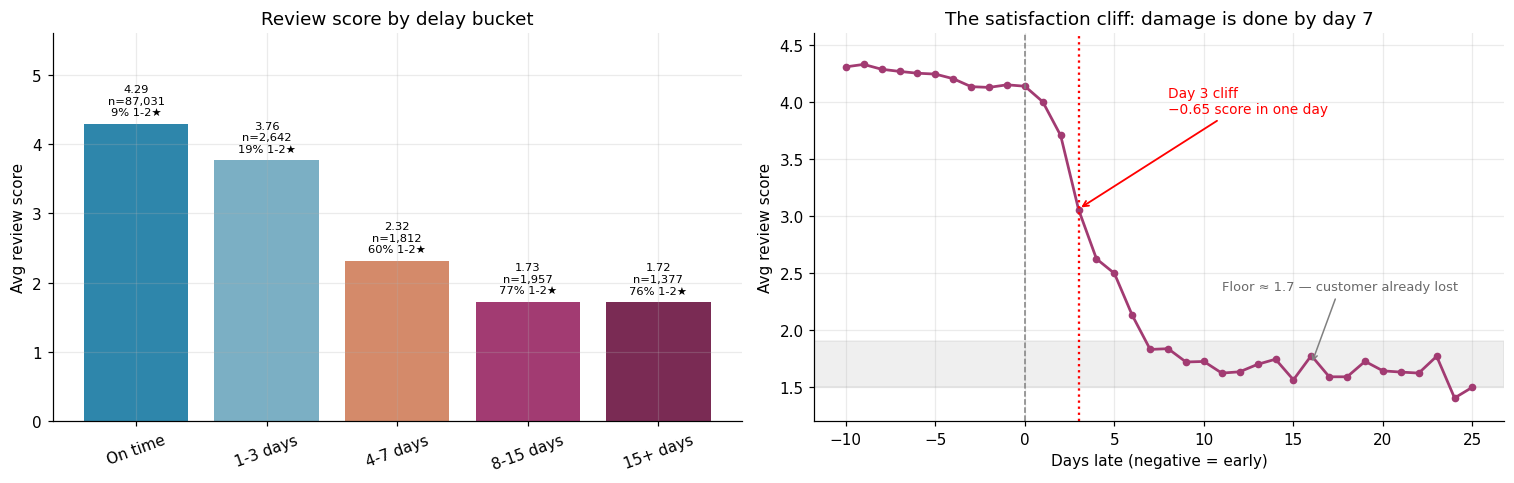

        score     n  day_drop
d                            
-10  4.304965   568       NaN
-9   4.326517  4573     0.022
-8   4.283983  4562    -0.043
-7   4.265234  4818    -0.019
-6   4.249263  4770    -0.016
-5   4.241681  3448    -0.008
-4   4.201270  2057    -0.040
-3   4.131523  1892    -0.070
-2   4.125075  1685    -0.006
-1   4.147705  1517     0.023
 0   4.135511  1446    -0.012
 1   3.999187  1243    -0.136
 2   3.704042   770    -0.295
 3   3.055777   512    -0.648
 4   2.623742   504    -0.432
 5   2.496644   460    -0.127
 6   2.128954   426    -0.368
 7   1.830549   430    -0.298
 8   1.837054   460     0.007
 9   1.720497   327    -0.117
 10  1.725118   219     0.005
 11  1.623188   207    -0.102
 12  1.634731   172     0.012
 13  1.700000   157     0.065
 14  1.744792   196     0.045
 15  1.564246   182    -0.181
 16  1.776978   142     0.213
 17  1.590909    92    -0.186
 18  1.590909    88     0.000
 19  1.726027    77     0.135
 20  1.642857    74    -0.083
 21  1.632

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,4.5))

# ---- left: bucket view ----
b = (fda.groupby('delay_bucket', observed=True)
       .agg(score=('review_score','mean'),
            pct12=('review_score', lambda s:(s<=2).mean()*100),
            n=('order_id','count')))
b = b.reindex(['On time','1-3 days','4-7 days','8-15 days','15+ days'])

ax[0].bar(b.index, b.score, color=['#2E86AB','#7BAFC4','#D48A6A','#A23B72','#7A2B54'])
ax[0].set_ylabel('Avg review score'); ax[0].set_ylim(0,5.6)
ax[0].set_title('Review score by delay bucket')
for i,(v,n,p) in enumerate(zip(b.score, b.n, b.pct12)):
    ax[0].text(i, v+.12, f'{v:.2f}\nn={n:,}\n{p:.0f}% 1-2★', ha='center', fontsize=7.5)
ax[0].tick_params(axis='x', rotation=20)

# ---- right: day-by-day cliff ----
f = fda[fda.days_late.between(-10,25)].copy()
f['d'] = f.days_late.round().astype(int)
g = f.groupby('d').agg(score=('review_score','mean'), n=('order_id','count'))
g = g[g.n >= 30]

ax[1].plot(g.index, g['score'], marker='o', ms=4, color='#A23B72', lw=1.8)
ax[1].axvline(0, ls='--', c='grey', lw=1)
ax[1].axvline(3, ls=':', c='red', lw=1.5)
ax[1].axhspan(1.5, 1.9, color='grey', alpha=.12)
ax[1].annotate('Day 3 cliff\n−0.65 score in one day',
               xy=(3, 3.06), xytext=(8, 3.9),
               arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
               fontsize=9, color='red')
ax[1].annotate('Floor ≈ 1.7 — customer already lost',
               xy=(16, 1.7), xytext=(11, 2.35),
               arrowprops=dict(arrowstyle='->', color='grey', lw=1),
               fontsize=8.5, color='dimgrey')
ax[1].set_xlabel('Days late (negative = early)')
ax[1].set_ylabel('Avg review score')
ax[1].set_title('The satisfaction cliff: damage is done by day 7')
ax[1].set_ylim(1.2, 4.6)

plt.tight_layout(); plt.show()

# ---- supporting numbers (bracket access, not dot access) ----
out = g.assign(day_drop=g['score'].diff().round(3))
print(out.to_string())

print(f"\nsteepest single-day drop: day {out['day_drop'].idxmin()} ({out['day_drop'].min():.3f})")
print(f"score at day 0: {g.loc[0,'score']:.2f}  |  day 3: {g.loc[3,'score']:.2f}  |  day 7: {g.loc[7,'score']:.2f}")
print(f"decline day 0→3:  {(g.loc[3,'score']/g.loc[0,'score']-1)*100:.1f}%")
print(f"decline day 7→25: {(g.loc[25,'score']/g.loc[7,'score']-1)*100:.1f}%   (flat = already lost)")

# cumulative damage framing
late = fda[fda.is_late==1]
print(f"\nlate orders: {len(late):,} ({len(late)/len(fda)*100:.2f}% of all)")
print(f"  1-3 days late: {(late.days_late<=3).sum():,} orders — {(late.days_late<=3).mean()*100:.1f}% of late volume")
print(f"  these are the recoverable ones; beyond day 7 score is flat at ~1.7")

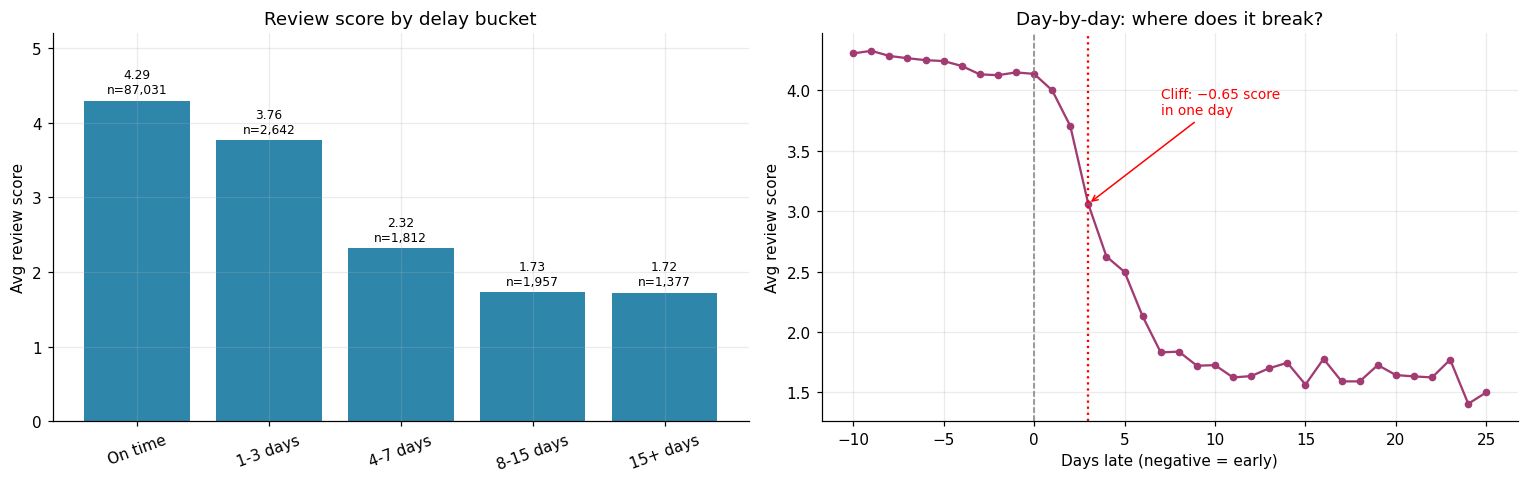

        score     n   drop
d                         
-10  4.304965   568    NaN
-9   4.326517  4573  0.022
-8   4.283983  4562 -0.043
-7   4.265234  4818 -0.019
-6   4.249263  4770 -0.016
-5   4.241681  3448 -0.008
-4   4.201270  2057 -0.040
-3   4.131523  1892 -0.070
-2   4.125075  1685 -0.006
-1   4.147705  1517  0.023
 0   4.135511  1446 -0.012
 1   3.999187  1243 -0.136
 2   3.704042   770 -0.295
 3   3.055777   512 -0.648
 4   2.623742   504 -0.432
 5   2.496644   460 -0.127
 6   2.128954   426 -0.368
 7   1.830549   430 -0.298
 8   1.837054   460  0.007
 9   1.720497   327 -0.117
 10  1.725118   219  0.005
 11  1.623188   207 -0.102
 12  1.634731   172  0.012
 13  1.700000   157  0.065
 14  1.744792   196  0.045
 15  1.564246   182 -0.181
 16  1.776978   142  0.213
 17  1.590909    92 -0.186
 18  1.590909    88  0.000
 19  1.726027    77  0.135
 20  1.642857    74 -0.083
 21  1.632184    91 -0.011
 22  1.623377    79 -0.009
 23  1.770492    65  0.147
 24  1.405405    39 -0.365
 

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,4.5))

b = (fda.groupby('delay_bucket', observed=True)
       .agg(score=('review_score','mean'), pct12=('review_score', lambda s:(s<=2).mean()*100),
            n=('order_id','count')))
b = b.reindex(['On time','1-3 days','4-7 days','8-15 days','15+ days'])
ax[0].bar(b.index, b.score, color='#2E86AB')
ax[0].set_ylabel('Avg review score'); ax[0].set_ylim(0,5.2)
ax[0].set_title('Review score by delay bucket')
for i,(v,n) in enumerate(zip(b.score, b.n)):
    ax[0].text(i, v+.1, f'{v:.2f}\nn={n:,}', ha='center', fontsize=8)
ax[0].tick_params(axis='x', rotation=20)

f = fda[fda.days_late.between(-10,25)].copy()
f['d'] = f.days_late.round().astype(int)
g = f.groupby('d').agg(score=('review_score','mean'), n=('order_id','count'))
g = g[g.n>=30]
ax[1].plot(g.index, g.score, marker='o', ms=4, color='#A23B72')
ax[1].axvline(0, ls='--', c='grey', lw=1)
ax[1].set_xlabel('Days late (negative = early)'); ax[1].set_ylabel('Avg review score')
ax[1].set_title('Day-by-day: where does it break?')

# --- NEW ANNOTATION CODE ADDED HERE ---
ax[1].axvline(3, ls=':', c='red', lw=1.5)
ax[1].annotate('Cliff: −0.65 score\nin one day', xy=(3,3.06), xytext=(7,3.8),
               arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')
# --------------------------------------

plt.tight_layout(); plt.show()

print(g.assign(drop=g.score.diff().round(3)).to_string())

H1 is supported. Customer satisfaction remains relatively stable for on-time and slightly delayed deliveries but drops sharply once delays extend beyond approximately 2–6 days. Beyond this threshold, review scores stabilize near 1.7 stars, indicating that additional delay causes relatively little further decline in satisfaction.


How to explain it in an interview

"From my analysis, I found that customer satisfaction does not decline gradually. It drops sharply once deliveries become several days late. Therefore, instead of trying to reduce delivery time for every order, I recommend implementing a delay prediction and alert system. Orders approaching the critical delay threshold should be automatically flagged and prioritized. Since carrier transit time has the strongest impact on total delivery time, the company should also monitor carrier performance using KPIs such as on-time delivery rate and average transit time. This targeted approach is likely to improve customer satisfaction more efficiently than applying the same logistics effort to all shipments."

H2 — The padded promise

Statement: Olist's 91.79% OTDR is achieved by setting a conservative delivery estimate, not by fast delivery. The promise exceeds actual performance by roughly 12 days.

Why it matters: It reframes OTDR as a vanity metric. Proved if the gap between promised and actual is large and stable over time.

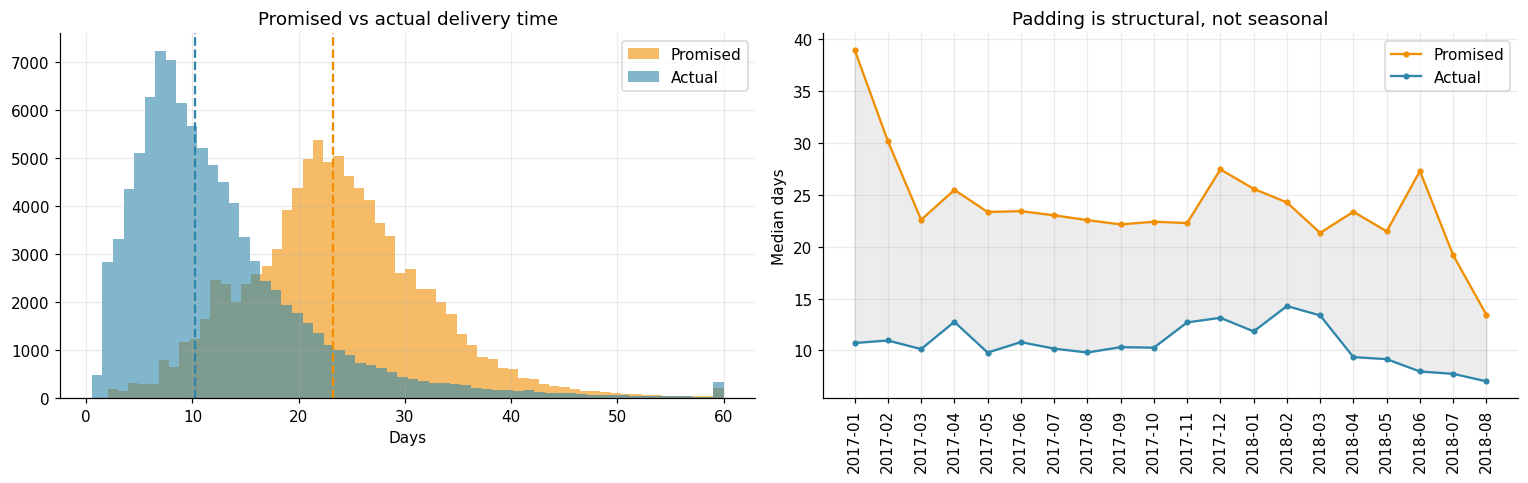

median promised 23.2d | actual 10.3d | buffer 13.0d


In [ ]:
fda['promised'] = fda.total_days - fda.days_late
fig, ax = plt.subplots(1,2, figsize=(14,4.5))

ax[0].hist(fda.promised.clip(0,60), bins=60, alpha=.6, label='Promised', color='#F18F01')
ax[0].hist(fda.total_days.clip(0,60), bins=60, alpha=.6, label='Actual', color='#2E86AB')
ax[0].axvline(fda.promised.median(), c='#F18F01', ls='--')
ax[0].axvline(fda.total_days.median(), c='#2E86AB', ls='--')
ax[0].set_xlabel('Days'); ax[0].legend(); ax[0].set_title('Promised vs actual delivery time')

m = fda.assign(mo=fda.purchase_date.dt.to_period('M').astype(str)).groupby('mo').agg(
        promised=('promised','median'), actual=('total_days','median'))
ax[1].plot(m.index, m.promised, marker='o', ms=3, label='Promised', color='#F18F01')
ax[1].plot(m.index, m.actual, marker='o', ms=3, label='Actual', color='#2E86AB')
ax[1].fill_between(m.index, m.actual, m.promised, alpha=.15, color='grey')
ax[1].tick_params(axis='x', rotation=90); ax[1].legend()
ax[1].set_ylabel('Median days'); ax[1].set_title('Padding is structural, not seasonal')
plt.tight_layout(); plt.show()

print(f"median promised {fda.promised.median():.1f}d | actual {fda.total_days.median():.1f}d | buffer {fda.promised.median()-fda.total_days.median():.1f}d")

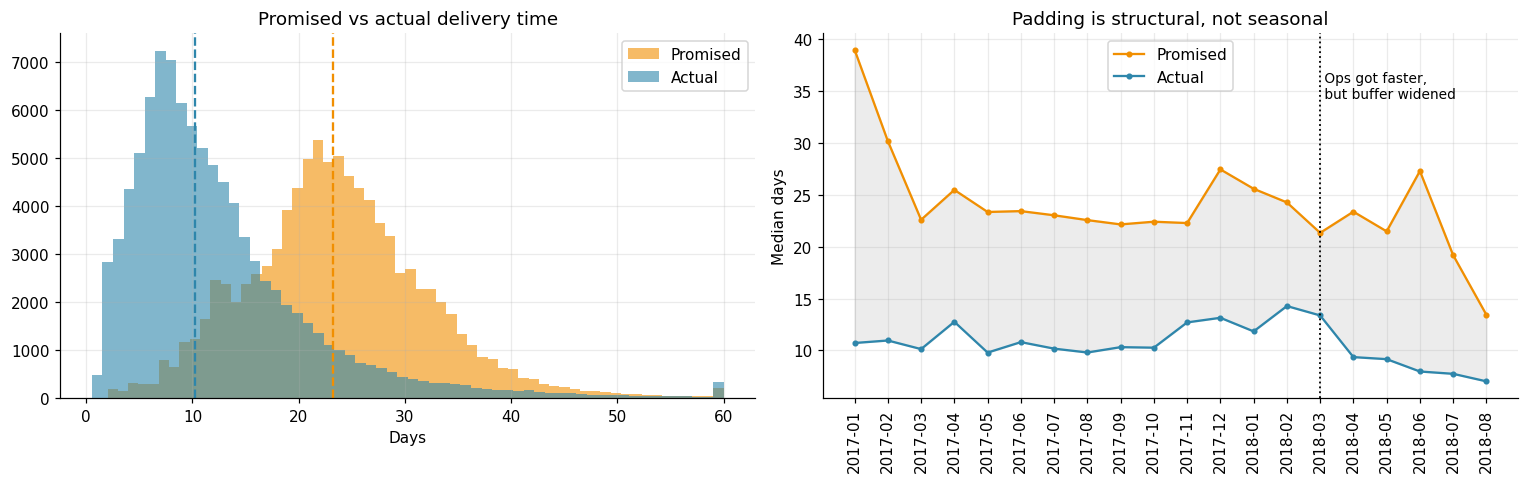

median promised 23.2d | actual 10.3d | buffer 13.0d


In [ ]:
fda['promised'] = fda.total_days - fda.days_late
fig, ax = plt.subplots(1,2, figsize=(14,4.5))

ax[0].hist(fda.promised.clip(0,60), bins=60, alpha=.6, label='Promised', color='#F18F01')
ax[0].hist(fda.total_days.clip(0,60), bins=60, alpha=.6, label='Actual', color='#2E86AB')
ax[0].axvline(fda.promised.median(), c='#F18F01', ls='--')
ax[0].axvline(fda.total_days.median(), c='#2E86AB', ls='--')
ax[0].set_xlabel('Days'); ax[0].legend(); ax[0].set_title('Promised vs actual delivery time')

m = fda.assign(mo=fda.purchase_date.dt.to_period('M').astype(str)).groupby('mo').agg(
        promised=('promised','median'), actual=('total_days','median'))
ax[1].plot(m.index, m.promised, marker='o', ms=3, label='Promised', color='#F18F01')
ax[1].plot(m.index, m.actual, marker='o', ms=3, label='Actual', color='#2E86AB')
ax[1].fill_between(m.index, m.actual, m.promised, alpha=.15, color='grey')

# --- NEW ANNOTATION CODE ADDED HERE ---
if '2018-03' in m.index:
    ax[1].axvline('2018-03', ls=':', c='black', lw=1.2)
    ax[1].text('2018-03', m.promised.max() - 2, ' Ops got faster,\n but buffer widened',
               fontsize=9, color='black', va='top')
# --------------------------------------

ax[1].tick_params(axis='x', rotation=90); ax[1].legend()
ax[1].set_ylabel('Median days'); ax[1].set_title('Padding is structural, not seasonal')
plt.tight_layout(); plt.show()

print(f"median promised {fda.promised.median():.1f}d | actual {fda.total_days.median():.1f}d | buffer {fda.promised.median()-fda.total_days.median():.1f}d")

H3 — Which leg owns the delay (REJECTED)

Statement: The seller handling leg drives delivery-time variance, so the fix is a seller SLA.

Why it matters: This is your deliberately-rejected hypothesis. The data says carrier, not seller. Rejected because leg_carrier correlates 0.93 with total time while leg_handling correlates 0.38

/tmp/ipykernel_1017/2721629999.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([fda_legs[l].clip(0,30) for l in legs], labels=names, showfliers=False)


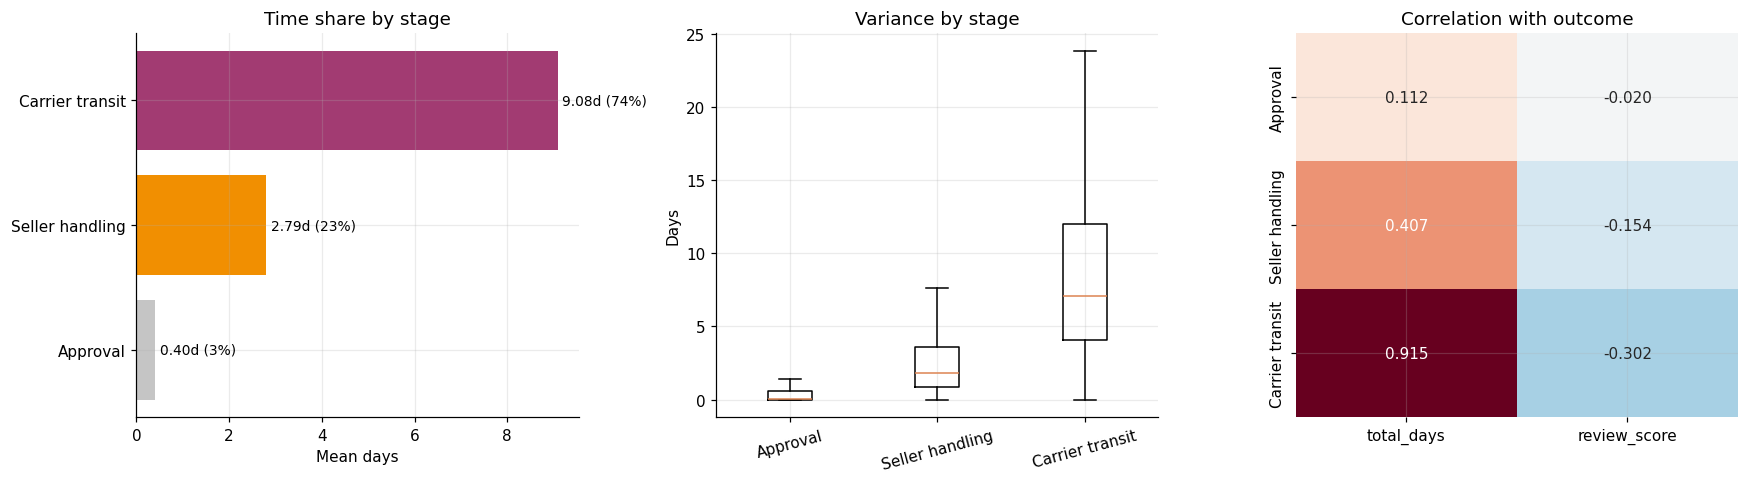

      leg_approval  leg_handling  leg_carrier
mean          0.40          2.79         9.08
std           0.80          3.21         7.39
max          30.89         49.59        53.29


In [ ]:
legs = ['leg_approval','leg_handling','leg_carrier']
names = ['Approval','Seller handling','Carrier transit']
fig, ax = plt.subplots(1,3, figsize=(16,4.5))

means = fda_legs[legs].mean()
ax[0].barh(names, means, color=['#C5C5C5','#F18F01','#A23B72'])
for i,v in enumerate(means): ax[0].text(v+.1, i, f'{v:.2f}d ({v/means.sum()*100:.0f}%)', va='center', fontsize=9)
ax[0].set_xlabel('Mean days'); ax[0].set_title('Time share by stage')

ax[1].boxplot([fda_legs[l].clip(0,30) for l in legs], labels=names, showfliers=False)
ax[1].set_ylabel('Days'); ax[1].set_title('Variance by stage')
ax[1].tick_params(axis='x', rotation=15)

c = fda_legs[legs+['total_days','review_score']].corr().loc[legs,['total_days','review_score']]
sns.heatmap(c, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax[2],
            yticklabels=names, cbar=False)
ax[2].set_title('Correlation with outcome')
plt.tight_layout(); plt.show()

print(fda_legs[legs].agg(['mean','std','max']).round(2))

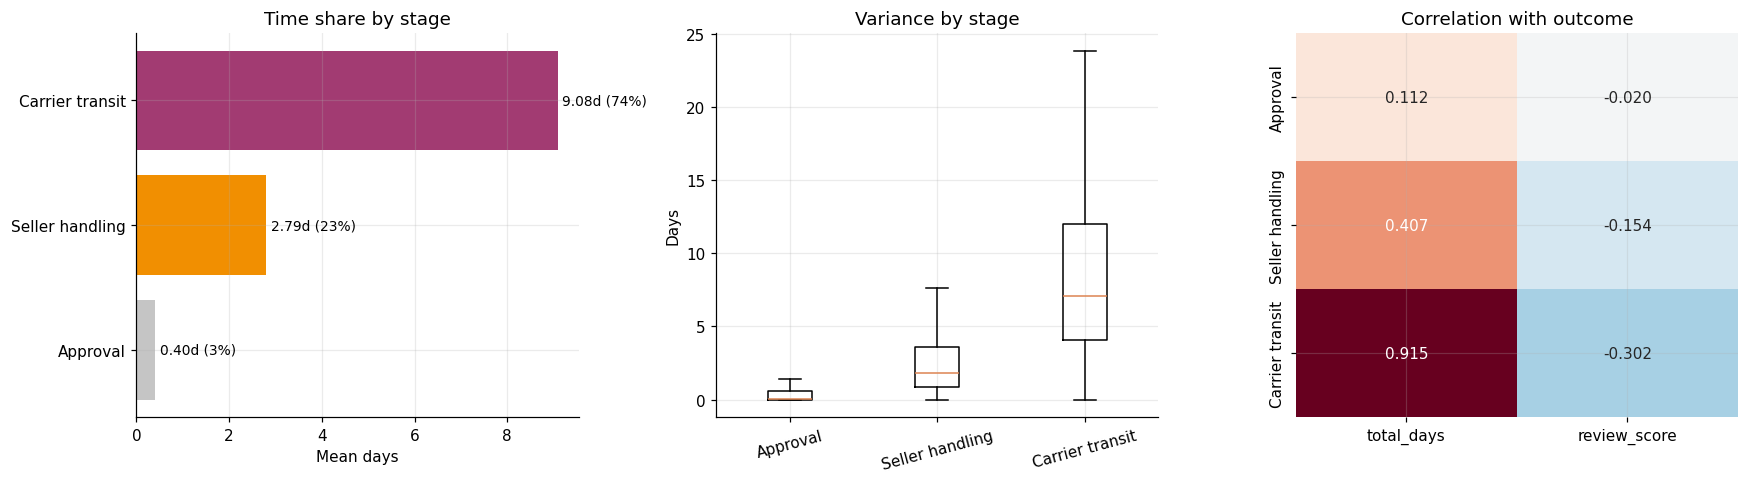

      leg_approval  leg_handling  leg_carrier
mean          0.40          2.79         9.08
std           0.80          3.21         7.39
max          30.89         49.59        53.29


In [ ]:
legs = ['leg_approval','leg_handling','leg_carrier']
names = ['Approval','Seller handling','Carrier transit']
fig, ax = plt.subplots(1,3, figsize=(16,4.5))

means = fda_legs[legs].mean()
ax[0].barh(names, means, color=['#C5C5C5','#F18F01','#A23B72'])
for i,v in enumerate(means):
    ax[0].text(v+.1, i, f'{v:.2f}d ({v/means.sum()*100:.0f}%)', va='center', fontsize=9)
ax[0].set_xlabel('Mean days'); ax[0].set_title('Time share by stage')

# --- UPDATED TO FIX MATPLOTLIB WARNING ---
ax[1].boxplot([fda_legs[l].clip(0,30) for l in legs], tick_labels=names, showfliers=False)
# ------------------------------------------

ax[1].set_ylabel('Days'); ax[1].set_title('Variance by stage')
ax[1].tick_params(axis='x', rotation=15)

c = fda_legs[legs+['total_days','review_score']].corr().loc[legs,['total_days','review_score']]
sns.heatmap(c, annot=True, fmt='.3f', cmap='RdBu_r', center=0, ax=ax[2],
            yticklabels=names, cbar=False)
ax[2].set_title('Correlation with outcome')
plt.tight_layout(); plt.show()

print(fda_legs[legs].agg(['mean','std','max']).round(2))

H4 — Distance from São Paulo drives failure

Statement: Late delivery concentrates in states far from São Paulo. Because 70.7% of sellers sit in SP, geography and supply concentration — not carrier quality — cause the failure.

Why it matters: Turns a heatmap into a structural explanation. Proved if high late-rate states are geographically distant and the SP→distant lanes underperform SP→SP.

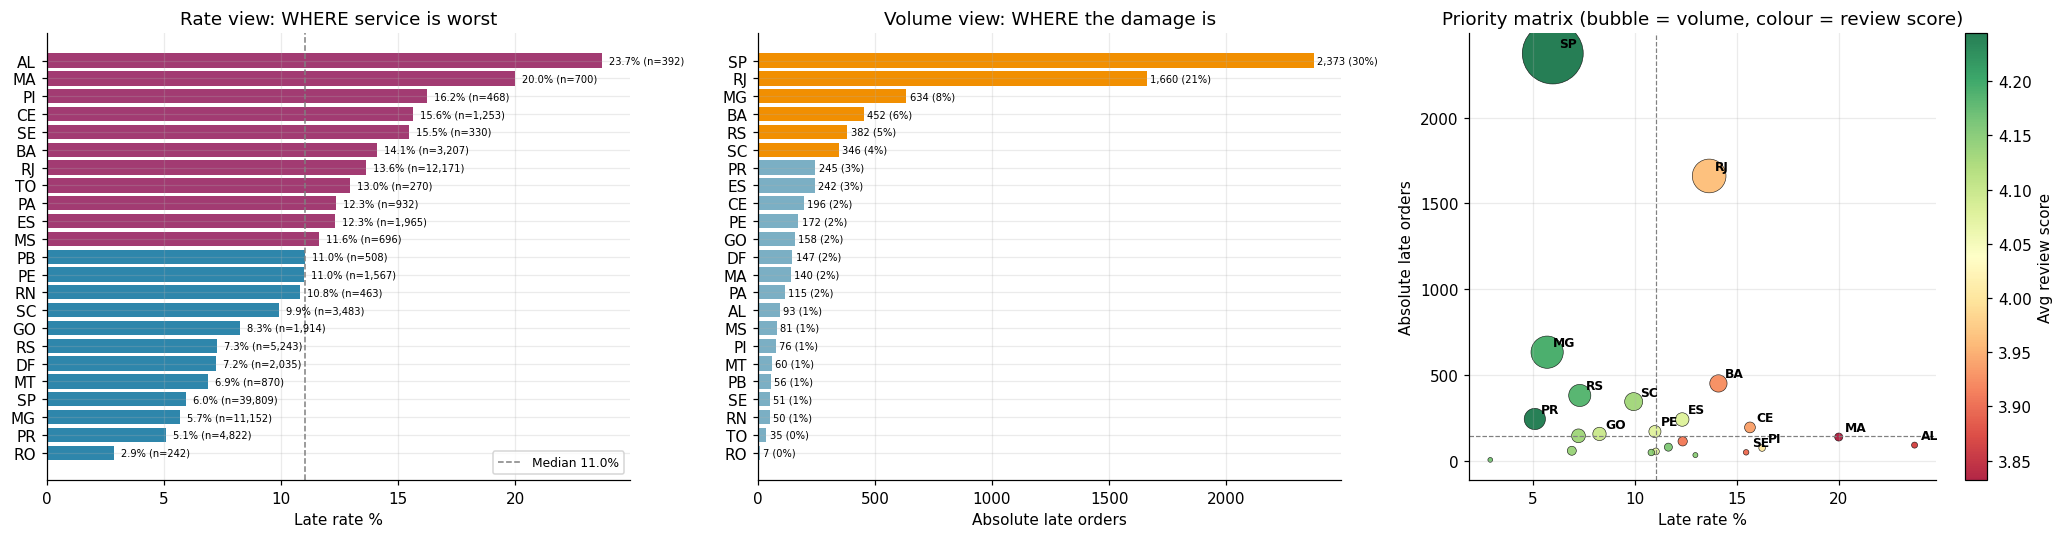

RANKED BY RATE (worst service):
                orders   late   days  score  late_orders
customer_state                                          
AL                 392  23.72  22.33   3.87           93
MA                 700  20.00  19.23   3.83          140
PI                 468  16.24  16.36   4.00           76
CE                1253  15.64  18.22   3.94          196
SE                 330  15.45  17.99   3.90           51
BA                3207  14.09  16.95   3.93          452
RJ               12171  13.64  12.08   3.96         1660
TO                 270  12.96  15.92   4.14           35

RANKED BY VOLUME (most damage):
                orders   late  late_orders  share_of_late  score
customer_state                                                  
SP               39809   5.96         2373           30.5   4.24
RJ               12171  13.64         1660           21.4   3.96
MG               11152   5.69          634            8.2   4.19
BA                3207  14.09          4

In [ ]:
st = (fda.groupby('customer_state').agg(
        orders=('order_id','count'),
        late=('is_late', lambda s: s.mean()*100),
        days=('total_days','median'),
        score=('review_score','mean'),
        neg=('review_score', lambda s: (s<=2).sum()))
      .query('orders>=200'))

st['late_orders'] = (st.orders * st.late / 100).round(0).astype(int)
st['share_of_late'] = (st.late_orders / st.late_orders.sum() * 100).round(1)
st['cum_share'] = st.sort_values('late_orders', ascending=False).share_of_late.cumsum()

fig, ax = plt.subplots(1, 3, figsize=(19, 5))

# ---- panel 1: RATE view ----
s = st.sort_values('late', ascending=True)
cols = ['#A23B72' if v > st.late.median() else '#2E86AB' for v in s.late]
ax[0].barh(s.index, s.late, color=cols)
ax[0].axvline(st.late.median(), ls='--', c='grey', lw=1, label=f'Median {st.late.median():.1f}%')
ax[0].set_xlabel('Late rate %'); ax[0].legend(fontsize=8)
ax[0].set_title('Rate view: WHERE service is worst')
for i, (v, n) in enumerate(zip(s.late, s.orders)):
    ax[0].text(v + .3, i, f'{v:.1f}% (n={n:,})', va='center', fontsize=6.5)

# ---- panel 2: VOLUME view ----
v = st.sort_values('late_orders', ascending=True)
cols2 = ['#F18F01' if x > v.late_orders.quantile(.75) else '#7BAFC4' for x in v.late_orders]
ax[1].barh(v.index, v.late_orders, color=cols2)
ax[1].set_xlabel('Absolute late orders'); ax[1].set_title('Volume view: WHERE the damage is')
for i, (x, p) in enumerate(zip(v.late_orders, v.share_of_late)):
    ax[1].text(x + 15, i, f'{x:,} ({p:.0f}%)', va='center', fontsize=6.5)

# ---- panel 3: the tradeoff ----
sc = ax[2].scatter(st.late, st.late_orders, s=st.orders/25, c=st.score,
                   cmap='RdYlGn', alpha=.85, edgecolor='k', lw=.4)
ax[2].axvline(st.late.median(), ls='--', c='grey', lw=.8)
ax[2].axhline(st.late_orders.median(), ls='--', c='grey', lw=.8)
for k, r in st.iterrows():
    if r.late_orders > 150 or r.late > 14:
        ax[2].annotate(k, (r.late, r.late_orders), fontsize=8,
                       xytext=(4, 4), textcoords='offset points', fontweight='bold')
ax[2].set_xlabel('Late rate %'); ax[2].set_ylabel('Absolute late orders')
ax[2].set_title('Priority matrix (bubble = volume, colour = review score)')
plt.colorbar(sc, ax=ax[2], label='Avg review score')

plt.tight_layout(); plt.show()

# ---- supporting output ----
print("RANKED BY RATE (worst service):")
print(st.nlargest(8, 'late')[['orders','late','days','score','late_orders']].round(2).to_string())

print("\nRANKED BY VOLUME (most damage):")
print(st.nlargest(8, 'late_orders')[['orders','late','late_orders','share_of_late','score']].round(2).to_string())

top3 = st.nlargest(3, 'late_orders')
print(f"\ntop 3 states by late volume = {top3.share_of_late.sum():.1f}% of ALL late orders")
print(f"top 5 = {st.nlargest(5,'late_orders').share_of_late.sum():.1f}%")

# ---- lane detail ----
lane = (fda.groupby(['seller_state','customer_state']).agg(
          n=('order_id','count'),
          late=('is_late', lambda s: s.mean()*100),
          days=('total_days','median'),
          score=('review_score','mean')).query('n>=150'))
lane['late_orders'] = (lane.n * lane.late / 100).round(0).astype(int)

print("\nSP-origin lanes by RATE:")
print(lane.loc['SP'].nlargest(8, 'late')[['n','late','days','score']].round(2).to_string())

print("\nSP-origin lanes by VOLUME of late orders:")
print(lane.loc['SP'].nlargest(8, 'late_orders')[['n','late','late_orders','days','score']].round(2).to_string())

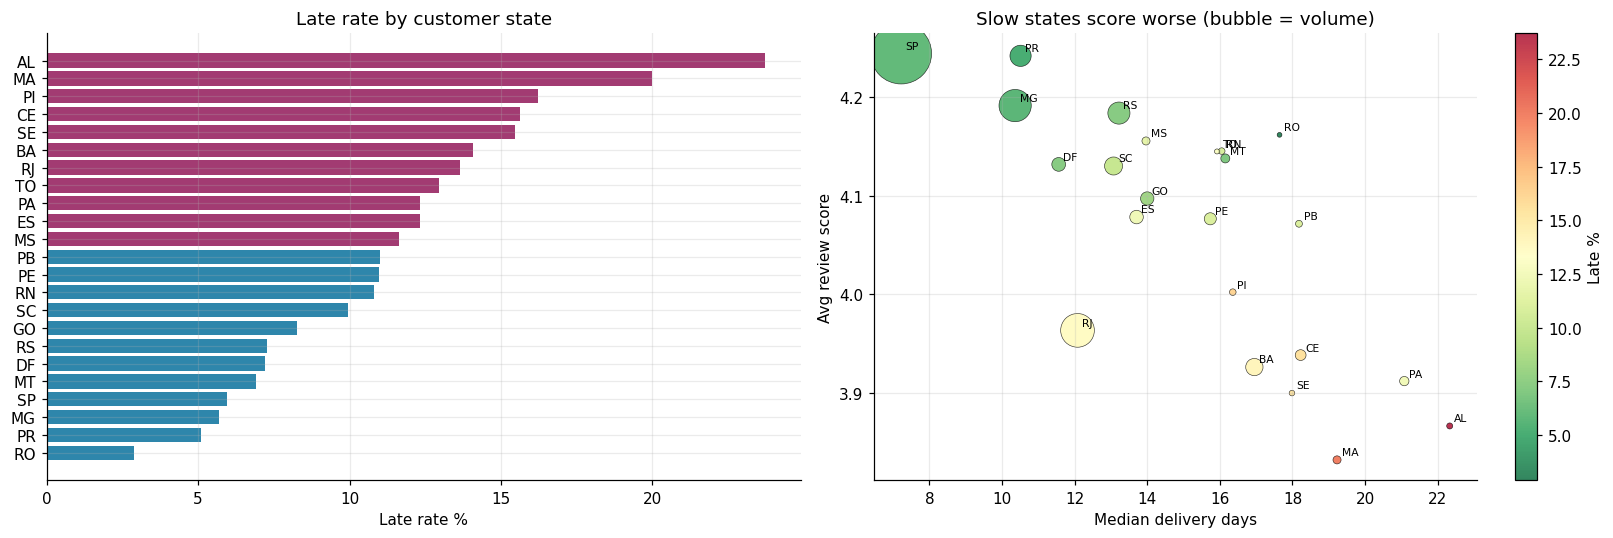


SP-origin lanes, worst 10:
                    n   late   days
customer_state                    
AL               253  26.09  22.97
MA               475  21.68  19.68
PI               325  18.46  16.82
SE               204  16.67  17.83
RJ              8017  15.72  12.89
CE               948  15.61  18.43
BA              2272  15.01  17.71
MS               471  14.65  14.03
ES              1441  14.30  13.67
PA               668  13.32  20.92


In [ ]:
st = (fda.groupby('customer_state').agg(orders=('order_id','count'),
        late=('is_late', lambda s:s.mean()*100), days=('total_days','median'),
        score=('review_score','mean')).query('orders>=200'))

fig, ax = plt.subplots(1,2, figsize=(15,5))
s = st.sort_values('late', ascending=True)
cols = ['#A23B72' if v>st.late.median() else '#2E86AB' for v in s.late]
ax[0].barh(s.index, s.late, color=cols)
ax[0].set_xlabel('Late rate %'); ax[0].set_title('Late rate by customer state')

sc = ax[1].scatter(st.days, st.score, s=st.orders/25, c=st.late, cmap='RdYlGn_r', alpha=.8, edgecolor='k', lw=.4)
for k,r in st.iterrows(): ax[1].annotate(k,(r.days,r.score), fontsize=7, xytext=(3,3), textcoords='offset points')
ax[1].set_xlabel('Median delivery days'); ax[1].set_ylabel('Avg review score')
ax[1].set_title('Slow states score worse (bubble = volume)')
plt.colorbar(sc, ax=ax[1], label='Late %')
plt.tight_layout(); plt.show()

lane = (fda.groupby(['seller_state','customer_state']).agg(n=('order_id','count'),
          late=('is_late', lambda s:s.mean()*100), days=('total_days','median')).query('n>=150'))
print("\nSP-origin lanes, worst 10:\n", lane.loc['SP'].sort_values('late', ascending=False).head(10).round(2).to_string())

H5 — Damage concentrates in the tail

Statement: Customer damage is not evenly distributed. A small tail of extremely slow deliveries produces a disproportionate share of all 1–2 star reviews.

Why it matters: Fixing the tail beats improving the average. Proved if the slowest decile contributes far more than 10% of negative reviews.

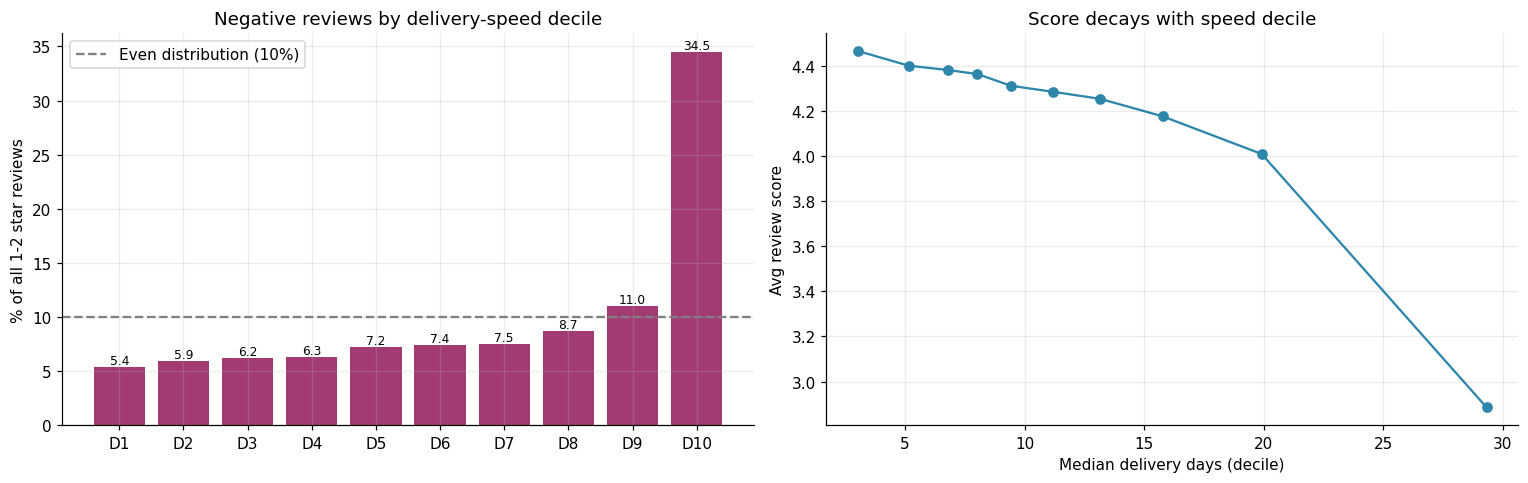

      neg     n   days  score  share_neg
dec                                     
D1    652  9482   3.03   4.47        5.4
D2    713  9482   5.16   4.40        5.9
D3    744  9482   6.80   4.38        6.2
D4    761  9483   8.03   4.36        6.3
D5    865  9481   9.43   4.31        7.2
D6    891  9481  11.17   4.28        7.4
D7    905  9482  13.16   4.25        7.5
D8   1055  9482  15.77   4.18        8.7
D9   1333  9482  19.91   4.01       11.0
D10  4166  9482  29.31   2.89       34.5

Slowest 2 deciles = 45.5% of all negative reviews (20% of orders)


In [ ]:
fda['dec'] = pd.qcut(fda.total_days, 10, labels=[f'D{i}' for i in range(1,11)])
d = fda.groupby('dec', observed=True).agg(neg=('review_score', lambda s:(s<=2).sum()),
        n=('order_id','count'), days=('total_days','median'), score=('review_score','mean'))
d['share_neg'] = (d.neg/d.neg.sum()*100).round(1)

fig, ax = plt.subplots(1,2, figsize=(14,4.5))
ax[0].bar(d.index, d.share_neg, color='#A23B72')
ax[0].axhline(10, ls='--', c='grey', label='Even distribution (10%)')
ax[0].set_ylabel('% of all 1-2 star reviews'); ax[0].legend()
ax[0].set_title('Negative reviews by delivery-speed decile')
for i,v in enumerate(d.share_neg): ax[0].text(i, v+.3, f'{v}', ha='center', fontsize=8)

ax[1].plot(d.days, d.score, marker='o', color='#2E86AB')
ax[1].set_xlabel('Median delivery days (decile)'); ax[1].set_ylabel('Avg review score')
ax[1].set_title('Score decays with speed decile')
plt.tight_layout(); plt.show()

print(d.round(2).to_string())
print(f"\nSlowest 2 deciles = {d.share_neg.tail(2).sum():.1f}% of all negative reviews (20% of orders)")

PROJECT 2 — Sales, Finance & Revenue

Run the setup cell first if your session restarted:

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
plt.rcParams.update({'figure.dpi':110,'font.size':10,'axes.grid':True,
                     'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False})

P = '/content/drive/MyDrive/olist_project/processed/'
fs = pd.read_csv(P+'fact_sales.csv')
fs['freight_ratio'] = fs.freight_value / fs.price.replace(0, np.nan)

ol = fs.groupby('order_id').agg(
        revenue=('price','sum'), freight=('freight_value','sum'),
        items=('order_item_id','count'), month=('purchase_month','first'),
        payment_type=('payment_type','first'), installments=('installments','first'),
        state=('customer_state','first')).reset_index()
print(f"{len(fs):,} items | {len(ol):,} orders")

109,880 items | 96,211 orders


H1 — Growth is volume-driven, not value-driven

Statement: Revenue growth over 2017–2018 comes from acquiring more orders, not from customers spending more per order. AOV is flat or declining while order count climbs.

Why it matters: These two paths need opposite investments. Volume growth means the lever is acquisition and marketing spend. Value growth means the lever is bundling, upsell, and merchandising. Getting this backwards misallocates the entire commercial budget. Proved if indexed orders rise sharply while indexed AOV stays flat or falls.

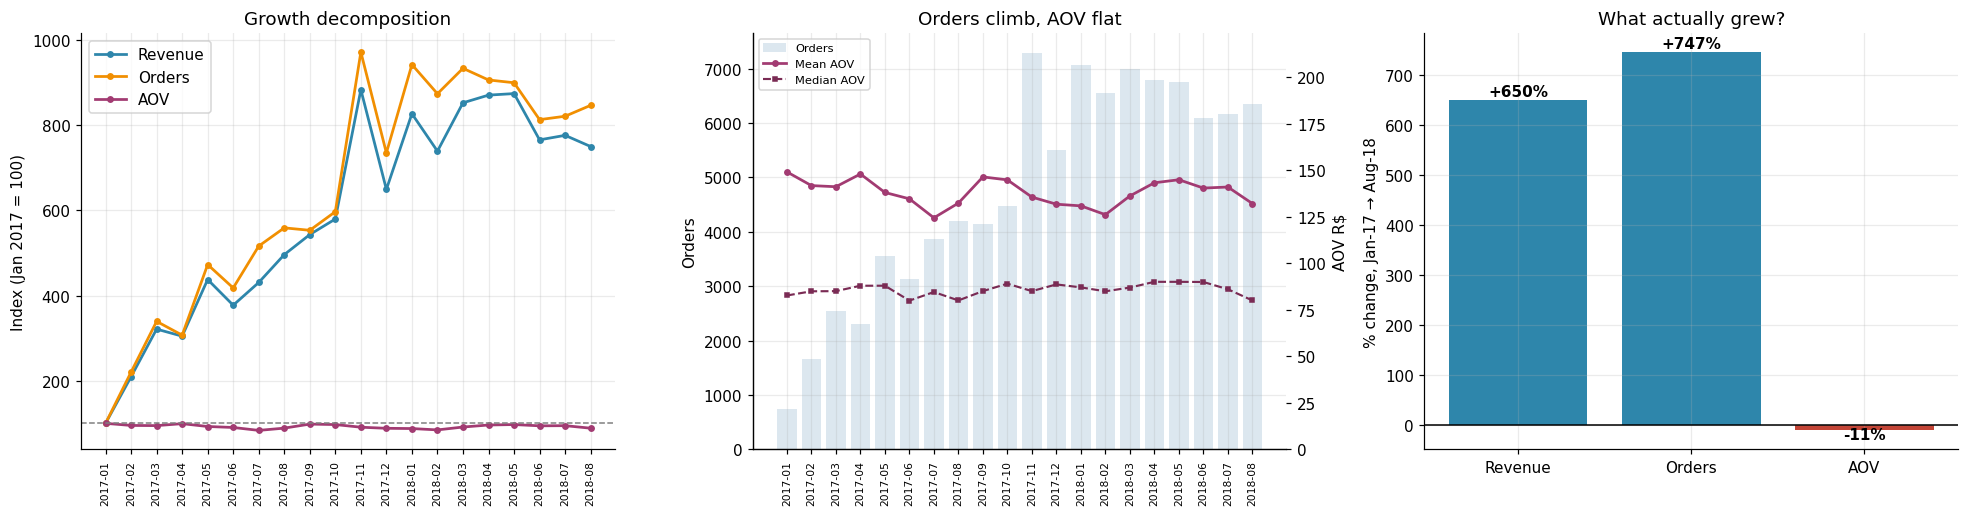

  month   revenue  orders    aov  aov_med  items
2017-01 111798.36     750 149.06    82.65   1.22
2017-02 234223.40    1653 141.70    84.90   1.12
2017-03 359198.85    2546 141.08    84.98   1.14
2017-04 340669.68    2303 147.92    87.89   1.12
2017-05 489338.25    3546 138.00    87.90   1.13
2017-06 421923.37    3135 134.58    79.90   1.11
2017-07 481604.52    3872 124.38    84.50   1.14
2017-08 554699.70    4193 132.29    79.99   1.14
2017-09 607399.67    4150 146.36    85.00   1.14
2017-10 648247.65    4478 144.76    89.00   1.16
2017-11 987765.37    7289 135.51    84.99   1.16
2017-12 726033.19    5513 131.69    88.60   1.12
2018-01 924645.00    7069 130.80    87.00   1.14
2018-02 826437.13    6555 126.08    84.90   1.15
2018-03 953356.25    7003 136.14    86.90   1.14
2018-04 973534.09    6798 143.21    89.99   1.15
2018-05 977544.69    6749 144.84    89.99   1.16
2018-06 856077.86    6099 140.36    89.90   1.15
2018-07 867953.46    6159 140.92    86.00   1.13
2018-08 838576.64   

In [ ]:
m = ol.groupby('month').agg(revenue=('revenue','sum'), orders=('order_id','count'),
        aov=('revenue','mean'), aov_med=('revenue','median'),
        items=('items','mean')).reset_index()
m = m[m.month.between('2017-01','2018-08')].reset_index(drop=True)
idx = m.set_index('month')[['revenue','orders','aov']]
idx = idx / idx.iloc[0] * 100

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))

for c, col, lab in zip(['revenue','orders','aov'],
                       ['#2E86AB','#F18F01','#A23B72'],
                       ['Revenue','Orders','AOV']):
    ax[0].plot(idx.index, idx[c], marker='o', ms=3.5, label=lab, color=col, lw=1.8)
ax[0].axhline(100, ls='--', c='grey', lw=1)
ax[0].legend(); ax[0].set_ylabel('Index (Jan 2017 = 100)')
ax[0].tick_params(axis='x', rotation=90, labelsize=7)
ax[0].set_title('Growth decomposition')

ax[1].bar(m.month, m.orders, color='#DCE7EF', label='Orders')
ax2 = ax[1].twinx()
ax2.plot(m.month, m.aov, color='#A23B72', marker='o', ms=3.5, lw=1.8, label='Mean AOV')
ax2.plot(m.month, m.aov_med, color='#7A2B54', marker='s', ms=3, ls='--', lw=1.4, label='Median AOV')
ax2.set_ylim(0, max(m.aov)*1.5); ax2.grid(False); ax2.set_ylabel('AOV R$')
ax[1].tick_params(axis='x', rotation=90, labelsize=7); ax[1].set_ylabel('Orders')
ax[1].set_title('Orders climb, AOV flat')
h1_, l1_ = ax[1].get_legend_handles_labels(); h2_, l2_ = ax2.get_legend_handles_labels()
ax[1].legend(h1_+h2_, l1_+l2_, fontsize=7.5, loc='upper left')

growth = pd.Series({'Revenue': idx.revenue.iloc[-1]-100,
                    'Orders': idx.orders.iloc[-1]-100,
                    'AOV': idx.aov.iloc[-1]-100})
ax[2].bar(growth.index, growth.values,
          color=['#2E86AB' if v>0 else '#C44536' for v in growth.values])
ax[2].axhline(0, c='k', lw=1); ax[2].set_ylabel('% change, Jan-17 → Aug-18')
ax[2].set_title('What actually grew?')
for i, v in enumerate(growth.values):
    ax[2].text(i, v + (8 if v>0 else -18), f'{v:+.0f}%', ha='center', fontweight='bold')

plt.tight_layout(); plt.show()

print(m[['month','revenue','orders','aov','aov_med','items']].round(2).to_string(index=False))
print(f"\nrevenue {idx.revenue.iloc[-1]-100:+.0f}%  |  orders {idx.orders.iloc[-1]-100:+.0f}%  |  AOV {idx.aov.iloc[-1]-100:+.0f}%")
print(f"AOV corr with time: {np.corrcoef(range(len(m)), m.aov)[0,1]:.3f}")
print(f"items/order Jan-17 {m['items'].iloc[0]:.3f} → Aug-18 {m['items'].iloc[-1]:.3f}")

H2 — There is a freight break-even price floor

Statement: Freight ratio is inversely related to item price (r = −0.292). Below a specific price point, shipping consumes so much of order value that the transaction is structurally uneconomic.

Why it matters: This produces a single number a category manager can act on tomorrow — a minimum viable price for the catalogue. It also explains why free-shipping thresholds exist and where to set one. Proved if freight ratio rises sharply in the low price deciles and a clear break point exists.

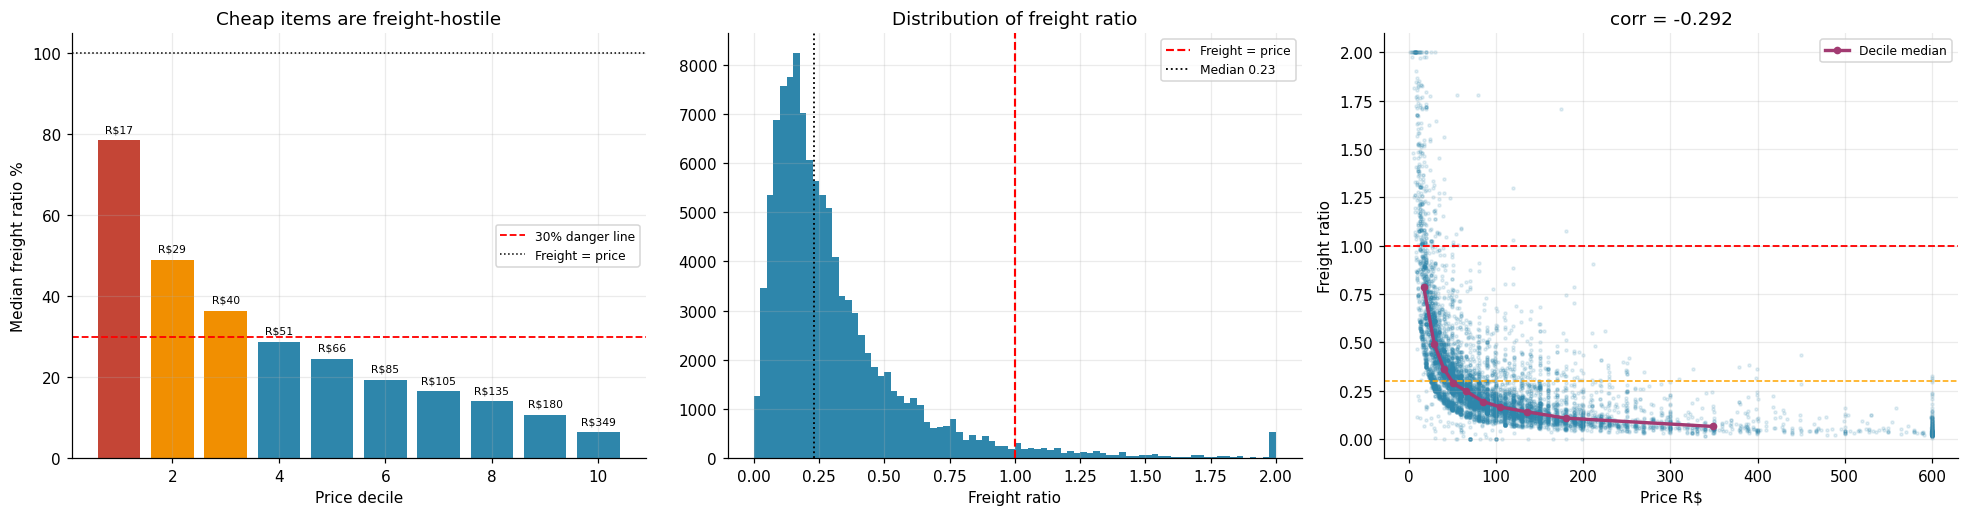

        pmin     pmax   price  freight     fr      n  rev_share
pdec                                                           
1       0.85    23.80   17.00   14.100  0.785  10993        1.4
2      23.89    34.90   29.00   14.520  0.490  11434        2.5
3      34.92    47.49   39.90   15.100  0.364  10604        3.3
4      47.50    59.00   50.99   15.140  0.288  11143        4.4
5      59.10    74.90   65.99   16.180  0.246  10843        5.4
6      74.98    94.99   84.90   16.320  0.193  10938        7.0
7      95.00   119.60  104.99   17.395  0.165  10966        8.8
8     119.70   150.00  134.90   18.640  0.140  11215       11.5
9     150.24   228.00  179.99   19.200  0.107  10761       15.0
10    228.09  6735.00  349.00   23.600  0.064  10983       40.7

4,000 items (3.64%) have freight EXCEEDING price
  their median price:  R$ 13.90   (overall R$ 74.90)
  revenue at risk:     R$ 69,915 (0.53% of total)

break-even: freight ratio crosses 30% below decile 3 (≈ R$ 47.49)
revenue belo

In [ ]:
fs['pdec'] = pd.qcut(fs.price, 10, labels=False) + 1
d = fs.groupby('pdec').agg(price=('price','median'), pmin=('price','min'), pmax=('price','max'),
        fr=('freight_ratio','median'), freight=('freight_value','median'),
        n=('order_id','count'), rev=('price','sum'))
d['rev_share'] = (d.rev / d.rev.sum() * 100).round(1)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))

bars = ax[0].bar(d.index, d.fr*100,
                 color=['#C44536' if v>.50 else '#F18F01' if v>.30 else '#2E86AB' for v in d.fr])
ax[0].axhline(30, ls='--', c='red', lw=1.2, label='30% danger line')
ax[0].axhline(100, ls=':', c='k', lw=1, label='Freight = price')
ax[0].legend(fontsize=8); ax[0].set_xlabel('Price decile')
ax[0].set_ylabel('Median freight ratio %'); ax[0].set_title('Cheap items are freight-hostile')
for x, v, p in zip(d.index, d.fr, d.price):
    ax[0].text(x, v*100+2, f'R${p:.0f}', ha='center', fontsize=7)

ax[1].hist(fs.freight_ratio.clip(0, 2), bins=80, color='#2E86AB')
ax[1].axvline(1, c='red', ls='--', lw=1.4, label='Freight = price')
ax[1].axvline(fs.freight_ratio.median(), c='k', ls=':', lw=1.2,
              label=f'Median {fs.freight_ratio.median():.2f}')
ax[1].legend(fontsize=8); ax[1].set_xlabel('Freight ratio')
ax[1].set_title('Distribution of freight ratio')

s = fs.sample(min(8000, len(fs)), random_state=1)
ax[2].scatter(s.price.clip(0,600), s.freight_ratio.clip(0,2), s=4, alpha=.13, color='#2E86AB')
ax[2].axhline(1, c='red', ls='--', lw=1.2)
ax[2].axhline(.30, c='orange', ls='--', lw=1)
bench = fs.groupby('pdec').agg(p=('price','median'), f=('freight_ratio','median'))
ax[2].plot(bench.p.clip(0,600), bench.f.clip(0,2), c='#A23B72', lw=2.2, marker='o', ms=4,
           label='Decile median')
ax[2].legend(fontsize=8); ax[2].set_xlabel('Price R$'); ax[2].set_ylabel('Freight ratio')
ax[2].set_title(f'corr = {fs[["price","freight_ratio"]].corr().iloc[0,1]:.3f}')

plt.tight_layout(); plt.show()

print(d[['pmin','pmax','price','freight','fr','n','rev_share']].round(3).to_string())

bad = fs[fs.freight_ratio > 1]
print(f"\n{len(bad):,} items ({len(bad)/len(fs)*100:.2f}%) have freight EXCEEDING price")
print(f"  their median price:  R$ {bad.price.median():.2f}   (overall R$ {fs.price.median():.2f})")
print(f"  revenue at risk:     R$ {bad.price.sum():,.0f} ({bad.price.sum()/fs.price.sum()*100:.2f}% of total)")

cross = d[d.fr > .30]
if len(cross):
    print(f"\nbreak-even: freight ratio crosses 30% below decile {cross.index.max()} (≈ R$ {d.loc[cross.index.max(),'pmax']:.2f})")
print(f"revenue below that price point: {d.loc[:cross.index.max(),'rev_share'].sum():.1f}% of total")

H3 — Revenue rank is not value rank

Statement: The highest-revenue categories are not the most economically efficient once freight burden is applied. Freight is priced on physical bulk (weight ↔ freight r = 0.610), not order value, so heavy categories destroy value even at high ticket prices.

Why it matters: Management ranks categories by revenue. If that ranking misleads, investment flows to categories that generate turnover but consume margin in logistics. This produces a concrete reprice-or-delist shortlist. Proved if top-revenue categories appear in the high-freight-ratio quadrant.

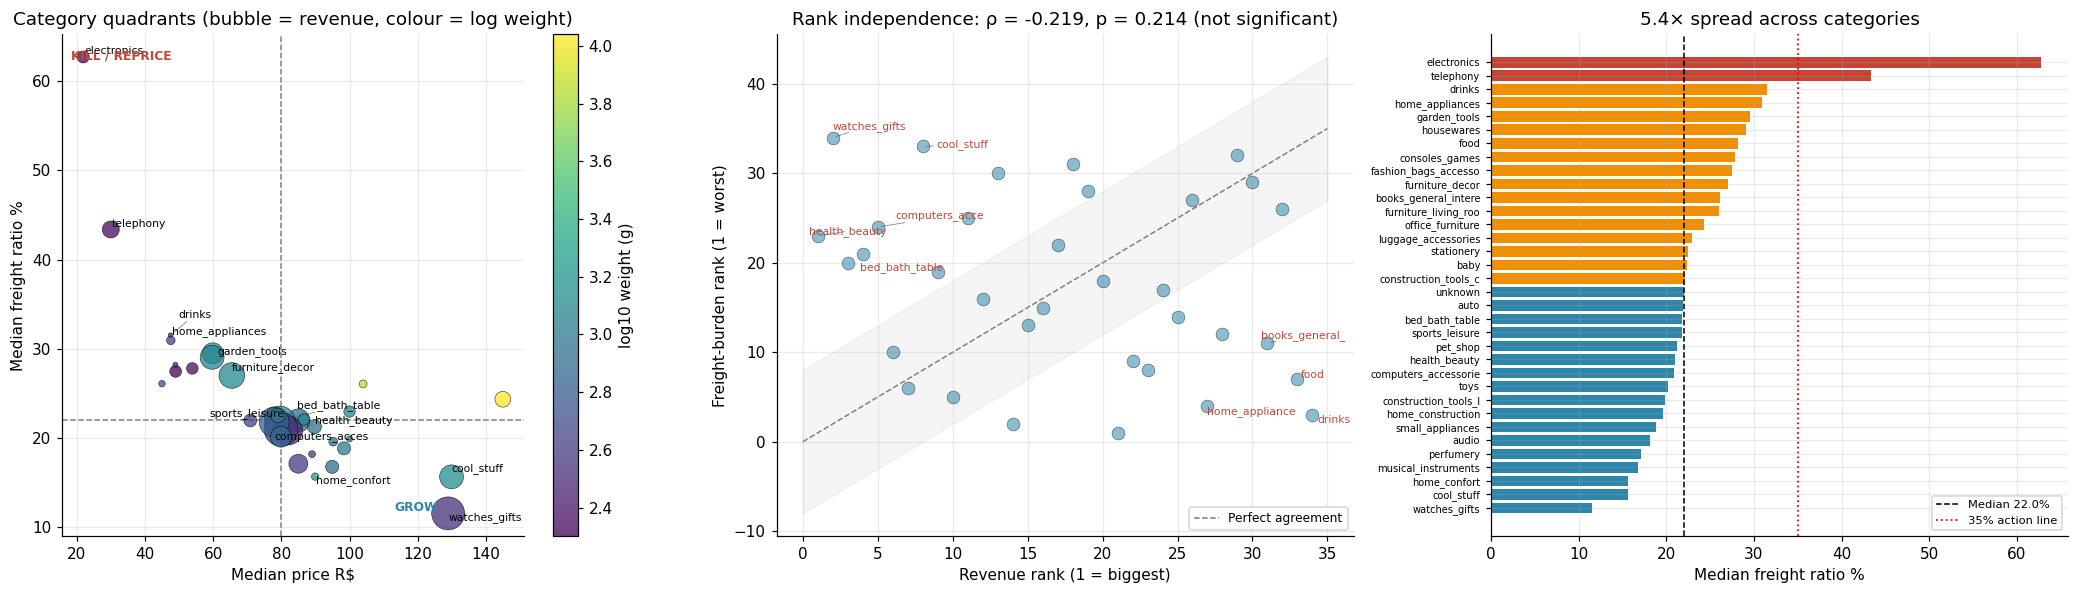

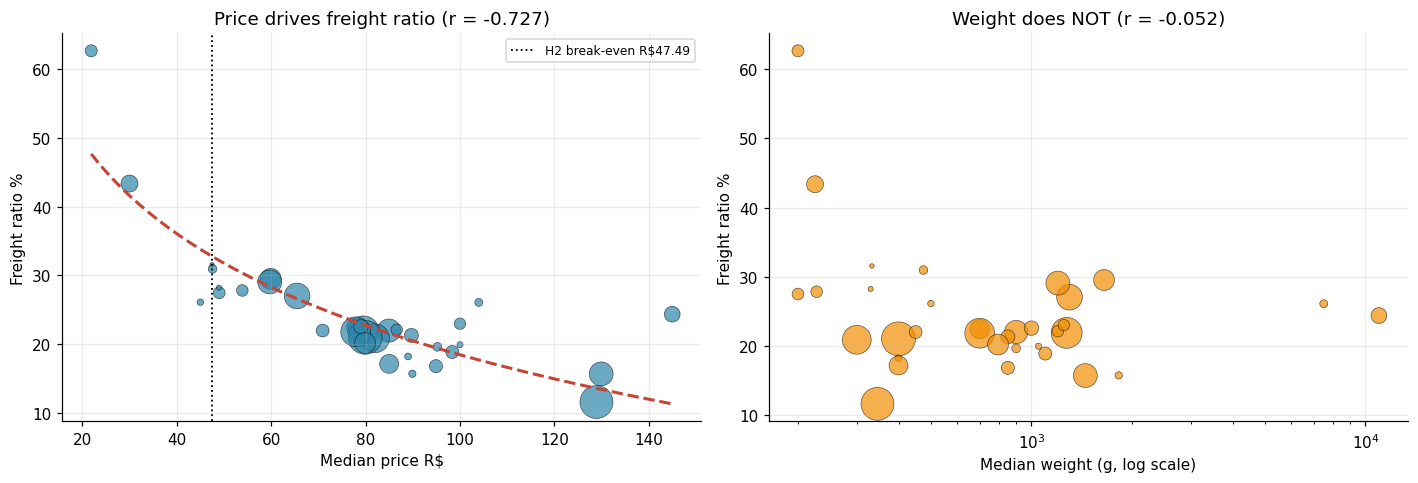

Spearman (revenue rank vs freight-burden rank): rho = -0.219, p = 0.2141
n = 34 categories → |rho| > ~0.34 needed for significance
→ no significant relationship: revenue rank carries no reliable information about freight health

freight ratio range: 0.116 (watches_gifts) → 0.627 (electronics)
spread: 5.4×   |   median 0.220

ACTION LIST — REPRICE/KILL (freight ratio > 35%):
             rev_share  price  freight     fr     wt     n
category                                                  
electronics       1.27  21.89     15.1  0.627  200.0  2728
telephony         2.53  29.99     15.1  0.434  225.0  4422
combined revenue exposure: 3.80%  (low risk to act on)

ACTION LIST — GROW (top-15 revenue AND freight ratio < median):
                       rev_share   price     fr      wt
category                                               
watches_gifts               9.51  128.90  0.116   346.0
cool_stuff                  4.98  129.90  0.157  1450.0
perfumery                   3.15   84.99  0

In [ ]:
!pip install -q adjustText
from adjustText import adjust_text
from scipy.stats import spearmanr

# ---------- build category table ----------
cat = (fs.groupby('category').agg(
        rev=('price','sum'), n=('order_item_id','count'),
        price=('price','median'), fr=('freight_ratio','median'),
        freight=('freight_value','median'), wt=('product_weight_g','median'),
        vol=('product_volume_cm3','median')).query('n>=300'))
cat['rev_share']    = (cat.rev / cat.rev.sum() * 100).round(2)
cat['rank_rev']     = cat.rev.rank(ascending=False)
cat['rank_fr']      = cat.fr.rank(ascending=False)
cat['gap']          = cat.rank_rev - cat.rank_fr
cat['freight_pool'] = cat.n * cat.freight

rho, pval = spearmanr(cat.rank_rev, cat.rank_fr)
BREAKEVEN = 47.49          # from H2
y0 = cat.fr.median()*100
x0 = cat.price.median()

# ================= FIGURE 1 =================
fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))

# ---- panel 1: quadrants ----
sc = ax[0].scatter(cat.price, cat.fr*100, s=cat.rev/2500, c=np.log10(cat.wt),
                   cmap='viridis', alpha=.75, edgecolor='k', lw=.4, zorder=3)
ax[0].axvline(x0, ls='--', c='grey', lw=1, zorder=1)
ax[0].axhline(y0, ls='--', c='grey', lw=1, zorder=1)

flag = pd.concat([cat.nlargest(5,'fr'), cat.nsmallest(3,'fr'), cat.nlargest(6,'rev')])
flag = flag[~flag.index.duplicated()]
t0 = [ax[0].text(r.price, r.fr*100, k[:15], fontsize=7) for k, r in flag.iterrows()]
adjust_text(t0, ax=ax[0], arrowprops=dict(arrowstyle='-', color='grey', lw=.5))

ax[0].text(.02,.97,'KILL / REPRICE', transform=ax[0].transAxes,
           fontsize=8, va='top', color='#C44536', fontweight='bold')
ax[0].text(.72,.05,'GROW', transform=ax[0].transAxes,
           fontsize=8, color='#2E86AB', fontweight='bold')
ax[0].set_xlabel('Median price R$'); ax[0].set_ylabel('Median freight ratio %')
ax[0].set_title('Category quadrants (bubble = revenue, colour = log weight)')
plt.colorbar(sc, ax=ax[0], label='log10 weight (g)')

# ---- panel 2: rank independence ----
ax[1].scatter(cat.rank_rev, cat.rank_fr, s=70, c='#2E86AB', alpha=.55,
              edgecolor='k', lw=.4, zorder=3)
lim = [0, len(cat)+1]
ax[1].plot(lim, lim, ls='--', c='grey', lw=1, zorder=1, label='Perfect agreement')
ax[1].fill_between(lim, [l-8 for l in lim], [l+8 for l in lim],
                   color='grey', alpha=.08, zorder=0)

lab = pd.concat([cat.nlargest(4,'gap'), cat.nsmallest(4,'gap'), cat.nlargest(3,'rev')])
lab = lab[~lab.index.duplicated()]
t1 = [ax[1].text(r.rank_rev, r.rank_fr, k[:14], fontsize=7, color='#C44536')
      for k, r in lab.iterrows()]
adjust_text(t1, ax=ax[1], arrowprops=dict(arrowstyle='-', color='grey', lw=.5))

ax[1].set_xlabel('Revenue rank (1 = biggest)')
ax[1].set_ylabel('Freight-burden rank (1 = worst)')
ax[1].legend(fontsize=8, loc='lower right')
ax[1].set_title(f'Rank independence: ρ = {rho:.3f}, p = {pval:.3f} (not significant)')

# ---- panel 3: full spread ----
srt = cat.sort_values('fr')
cols = ['#C44536' if v>.35 else '#F18F01' if v>y0/100 else '#2E86AB' for v in srt.fr]
ax[2].barh(range(len(srt)), srt.fr*100, color=cols)
ax[2].set_yticks(range(len(srt)))
ax[2].set_yticklabels([i[:20] for i in srt.index], fontsize=6.5)
ax[2].axvline(y0, ls='--', c='k', lw=1, label=f'Median {y0:.1f}%')
ax[2].axvline(35, ls=':', c='red', lw=1.2, label='35% action line')
ax[2].legend(fontsize=7.5); ax[2].set_xlabel('Median freight ratio %')
ax[2].set_title(f'{srt.fr.max()/srt.fr.min():.1f}× spread across categories')

plt.tight_layout(); plt.show()

# ================= FIGURE 2: the mechanism =================
fig2, ax2 = plt.subplots(1, 2, figsize=(13, 4.5))

ax2[0].scatter(cat.price, cat.fr*100, s=cat.rev/2500, c='#2E86AB',
               alpha=.7, edgecolor='k', lw=.4)
z = np.polyfit(np.log(cat.price), cat.fr*100, 1)
xs = np.linspace(cat.price.min(), cat.price.max(), 100)
ax2[0].plot(xs, np.polyval(z, np.log(xs)), c='#C44536', lw=2, ls='--')
ax2[0].axvline(BREAKEVEN, ls=':', c='k', lw=1.2, label=f'H2 break-even R${BREAKEVEN}')
ax2[0].legend(fontsize=8)
ax2[0].set_xlabel('Median price R$'); ax2[0].set_ylabel('Freight ratio %')
ax2[0].set_title(f'Price drives freight ratio (r = {cat[["price","fr"]].corr().iloc[0,1]:.3f})')

ax2[1].scatter(cat.wt, cat.fr*100, s=cat.rev/2500, c='#F18F01',
               alpha=.7, edgecolor='k', lw=.4)
ax2[1].set_xscale('log')
ax2[1].set_xlabel('Median weight (g, log scale)'); ax2[1].set_ylabel('Freight ratio %')
ax2[1].set_title(f'Weight does NOT (r = {cat[["wt","fr"]].corr().iloc[0,1]:.3f})')

plt.tight_layout(); plt.show()

# ================= OUTPUT =================
print(f"Spearman (revenue rank vs freight-burden rank): rho = {rho:.3f}, p = {pval:.4f}")
print(f"n = {len(cat)} categories → |rho| > ~0.34 needed for significance")
print("→ no significant relationship: revenue rank carries no reliable information about freight health\n")

print(f"freight ratio range: {cat.fr.min():.3f} ({cat.fr.idxmin()}) → {cat.fr.max():.3f} ({cat.fr.idxmax()})")
print(f"spread: {cat.fr.max()/cat.fr.min():.1f}×   |   median {cat.fr.median():.3f}\n")

print("ACTION LIST — REPRICE/KILL (freight ratio > 35%):")
kill = cat[cat.fr > .35].sort_values('fr', ascending=False)
print(kill[['rev_share','price','freight','fr','wt','n']].round(3).to_string())
print(f"combined revenue exposure: {kill.rev_share.sum():.2f}%  (low risk to act on)")

print("\nACTION LIST — GROW (top-15 revenue AND freight ratio < median):")
grow = cat.nlargest(15,'rev')
grow = grow[grow.fr < cat.fr.median()].sort_values('fr')
print(grow[['rev_share','price','fr','wt']].round(3).to_string())

print("\nWHAT DRIVES FREIGHT RATIO (category-level correlations):")
print(cat[['fr','price','wt','vol','rev_share']].corr()['fr'].round(3).to_string())

print(f"\n--- H2 / H3 CORROBORATION ---")
below = cat[cat.price < BREAKEVEN]
above = cat[cat.price >= BREAKEVEN]
print(f"categories priced below R${BREAKEVEN}: {len(below)} of {len(cat)}")
print(below[['rev_share','price','fr']].sort_values('fr', ascending=False).round(3).to_string())
print(f"\nmean freight ratio below break-even: {below.fr.mean():.3f}")
print(f"mean freight ratio above break-even: {above.fr.mean():.3f}")
print(f"both action-list categories sit below break-even: "
      f"{set(kill.index).issubset(set(below.index))}")

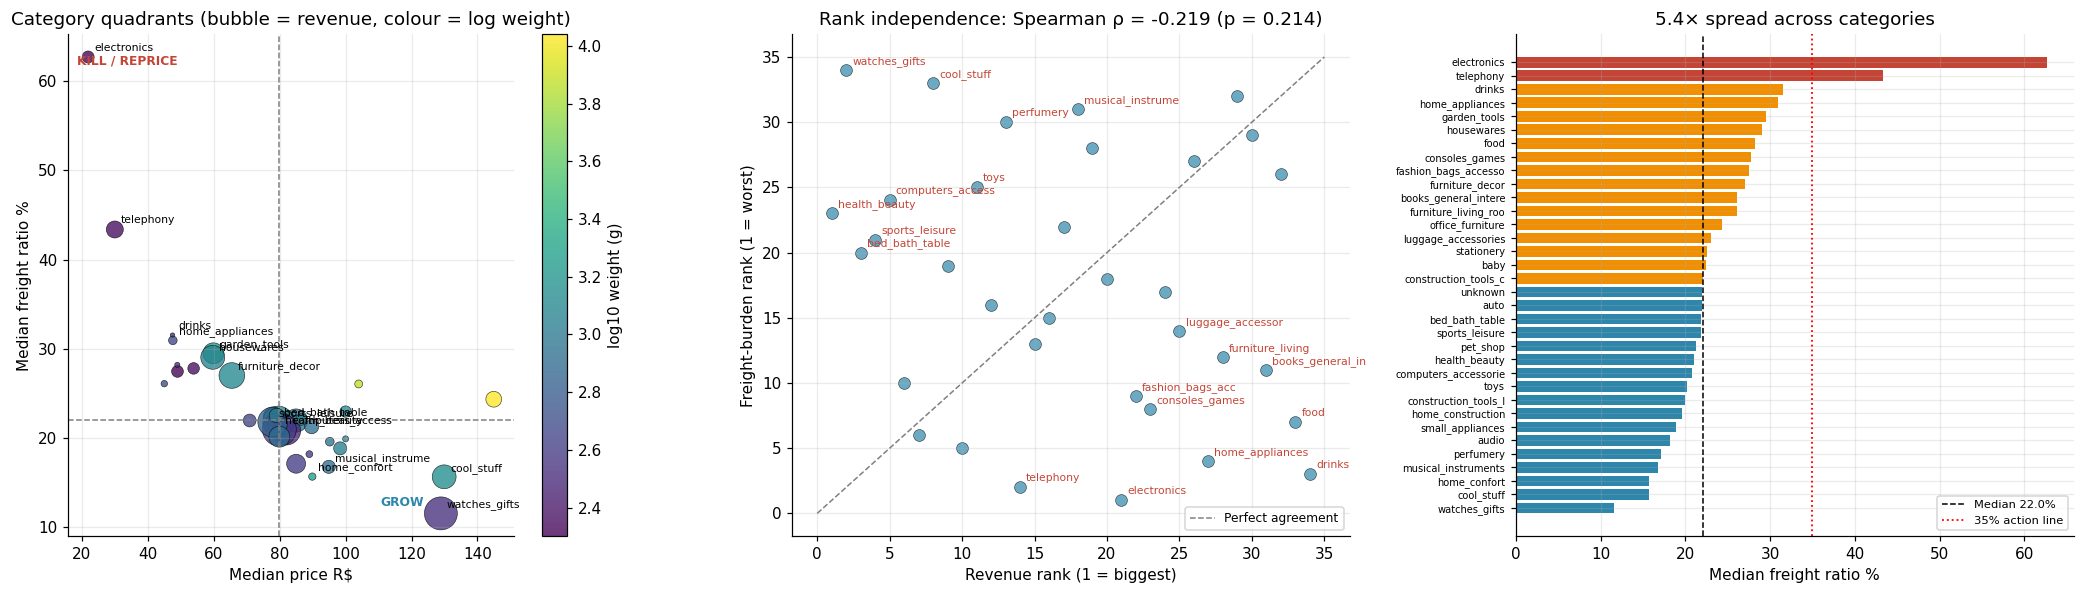

Spearman rank correlation (revenue rank vs freight-burden rank): rho = -0.219, p = 0.2141
→ near zero means revenue rank carries NO information about freight health

freight ratio range: 0.116 (watches_gifts) → 0.627 (electronics)
spread: 5.4×   |   median 0.220

ACTION LIST — REPRICE/KILL (freight ratio > 35%):
             rev_share  price  freight     fr     wt     n
category                                                  
electronics       1.27  21.89     15.1  0.627  200.0  2728
telephony         2.53  29.99     15.1  0.434  225.0  4422
combined revenue exposure: 3.80%

ACTION LIST — GROW (top-15 revenue AND freight ratio < median):
                       rev_share   price     fr      wt
category                                               
watches_gifts               9.51  128.90  0.116   346.0
cool_stuff                  4.98  129.90  0.157  1450.0
perfumery                   3.15   84.99  0.171   400.0
toys                        3.82   79.90  0.202   794.5
computers_access

In [ ]:
from scipy.stats import spearmanr

cat = (fs.groupby('category').agg(
        rev=('price','sum'), n=('order_item_id','count'),
        price=('price','median'), fr=('freight_ratio','median'),
        freight=('freight_value','median'), wt=('product_weight_g','median'),
        vol=('product_volume_cm3','median')).query('n>=300'))
cat['rev_share']  = (cat.rev / cat.rev.sum() * 100).round(2)
cat['rank_rev']   = cat.rev.rank(ascending=False)
cat['rank_fr']    = cat.fr.rank(ascending=False)
cat['gap']        = cat.rank_rev - cat.rank_fr
cat['freight_pool'] = cat.n * cat.freight          # total freight spend

rho, pval = spearmanr(cat.rank_rev, cat.rank_fr)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))

# ---- panel 1: quadrants ----
x0, y0 = cat.price.median(), cat.fr.median()*100
sc = ax[0].scatter(cat.price, cat.fr*100, s=cat.rev/2500, c=np.log10(cat.wt),
                   cmap='viridis', alpha=.78, edgecolor='k', lw=.4)
ax[0].axvline(x0, ls='--', c='grey', lw=1); ax[0].axhline(y0, ls='--', c='grey', lw=1)
flag = pd.concat([cat.nlargest(6,'fr'), cat.nsmallest(4,'fr'), cat.nlargest(6,'rev')])
for k, r in flag[~flag.index.duplicated()].iterrows():
    ax[0].annotate(k[:16], (r.price, r.fr*100), fontsize=7,
                   xytext=(4,4), textcoords='offset points')
ax[0].text(.02,.96,'KILL / REPRICE', transform=ax[0].transAxes,
           fontsize=8, va='top', color='#C44536', fontweight='bold')
ax[0].text(.70,.06,'GROW', transform=ax[0].transAxes,
           fontsize=8, color='#2E86AB', fontweight='bold')
ax[0].set_xlabel('Median price R$'); ax[0].set_ylabel('Median freight ratio %')
ax[0].set_title('Category quadrants (bubble = revenue, colour = log weight)')
plt.colorbar(sc, ax=ax[0], label='log10 weight (g)')

# ---- panel 2: rank independence — the actual test ----
ax[1].scatter(cat.rank_rev, cat.rank_fr, s=60, c='#2E86AB', alpha=.7, edgecolor='k', lw=.4)
lim = [0, len(cat)+1]
ax[1].plot(lim, lim, ls='--', c='grey', lw=1, label='Perfect agreement')
for k, r in cat[abs(cat.gap) > 10].iterrows():
    ax[1].annotate(k[:16], (r.rank_rev, r.rank_fr), fontsize=7,
                   xytext=(4,4), textcoords='offset points', color='#C44536')
ax[1].set_xlabel('Revenue rank (1 = biggest)')
ax[1].set_ylabel('Freight-burden rank (1 = worst)')
ax[1].legend(fontsize=8)
ax[1].set_title(f'Rank independence: Spearman ρ = {rho:.3f} (p = {pval:.3f})')

# ---- panel 3: the spread ----
srt = cat.sort_values('fr')
cols = ['#C44536' if v>.35 else '#F18F01' if v>y0/100 else '#2E86AB' for v in srt.fr]
ax[2].barh(range(len(srt)), srt.fr*100, color=cols)
ax[2].set_yticks(range(len(srt)))
ax[2].set_yticklabels([i[:20] for i in srt.index], fontsize=6.5)
ax[2].axvline(y0, ls='--', c='k', lw=1, label=f'Median {y0:.1f}%')
ax[2].axvline(35, ls=':', c='red', lw=1.2, label='35% action line')
ax[2].legend(fontsize=7.5); ax[2].set_xlabel('Median freight ratio %')
ax[2].set_title(f'{srt.fr.max()/srt.fr.min():.1f}× spread across categories')

plt.tight_layout(); plt.show()

# ---- the test result ----
print(f"Spearman rank correlation (revenue rank vs freight-burden rank): rho = {rho:.3f}, p = {pval:.4f}")
print("→ near zero means revenue rank carries NO information about freight health\n")
print(f"freight ratio range: {cat.fr.min():.3f} ({cat.fr.idxmin()}) → {cat.fr.max():.3f} ({cat.fr.idxmax()})")
print(f"spread: {cat.fr.max()/cat.fr.min():.1f}×   |   median {cat.fr.median():.3f}\n")

print("ACTION LIST — REPRICE/KILL (freight ratio > 35%):")
kill = cat[cat.fr > .35].sort_values('fr', ascending=False)
print(kill[['rev_share','price','freight','fr','wt','n']].round(3).to_string())
print(f"combined revenue exposure: {kill.rev_share.sum():.2f}%")

print("\nACTION LIST — GROW (top-15 revenue AND freight ratio < median):")
grow = cat.nlargest(15,'rev')
grow = grow[grow.fr < cat.fr.median()].sort_values('fr')
print(grow[['rev_share','price','fr','wt']].round(3).to_string())

print("\nWHAT DRIVES FREIGHT RATIO (category-level correlations):")
print(cat[['fr','price','wt','vol','rev_share']].corr()['fr'].round(3).to_string())

H4 — Installments lift AOV

Statement: Customers spend materially more when payment is split across installments. Installment availability is a revenue lever, not just a payment option.

Why it matters: Directly quantified finance recommendation. Proved if AOV rises monotonically across installment bands. Correlation is already +0.285.

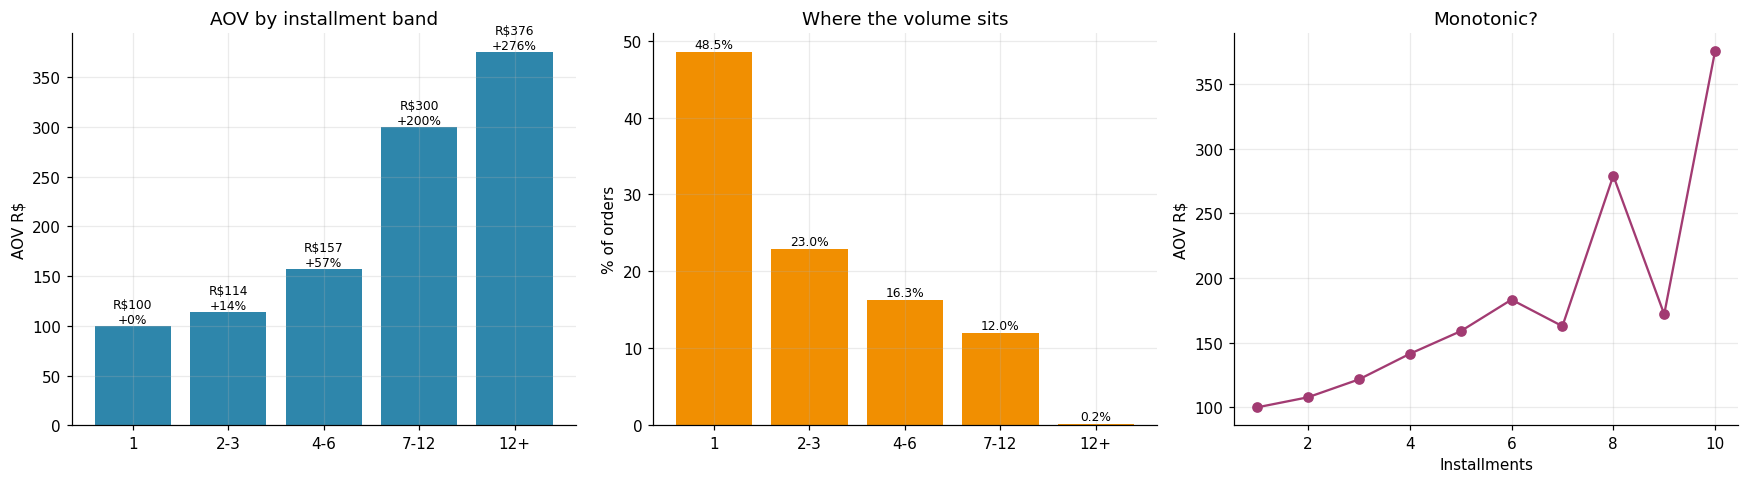

         aov     med      n         rev    lift  share
band                                                  
1      99.94   59.99  46709  4668200.07    0.00  48.55
2-3   114.05   90.00  22100  2520450.16   14.11  22.97
4-6   157.05  107.85  15686  2463529.83   57.14  16.30
7-12  300.08  179.00  11535  3461472.87  200.26  11.99
12+   375.67  219.90    179    67244.92  275.89   0.19


In [ ]:
ol['band'] = pd.cut(ol.installments, [0,1,3,6,12,99], labels=['1','2-3','4-6','7-12','12+'])
b = ol.groupby('band', observed=True).agg(aov=('revenue','mean'), med=('revenue','median'),
        n=('order_id','count'), rev=('revenue','sum'))
b['lift'] = (b.aov/b.aov.iloc[0]-1)*100
b['share'] = b.n/b.n.sum()*100

fig, ax = plt.subplots(1,3, figsize=(16,4.5))
ax[0].bar(b.index, b.aov, color='#2E86AB'); ax[0].set_ylabel('AOV R$')
for i,(v,l) in enumerate(zip(b.aov,b.lift)): ax[0].text(i, v+3, f'R${v:.0f}\n{l:+.0f}%', ha='center', fontsize=8)
ax[0].set_title('AOV by installment band')

ax[1].bar(b.index, b.share, color='#F18F01'); ax[1].set_ylabel('% of orders')
ax[1].set_title('Where the volume sits')
for i,v in enumerate(b.share): ax[1].text(i, v+.5, f'{v:.1f}%', ha='center', fontsize=8)

i2 = ol[ol.installments.between(1,12)].groupby('installments').revenue.agg(['mean','count'])
i2 = i2[i2['count']>=200]
ax[2].plot(i2.index, i2['mean'], marker='o', color='#A23B72')
ax[2].set_xlabel('Installments'); ax[2].set_ylabel('AOV R$'); ax[2].set_title('Monotonic?')
plt.tight_layout(); plt.show()

print(b.round(2).to_string())

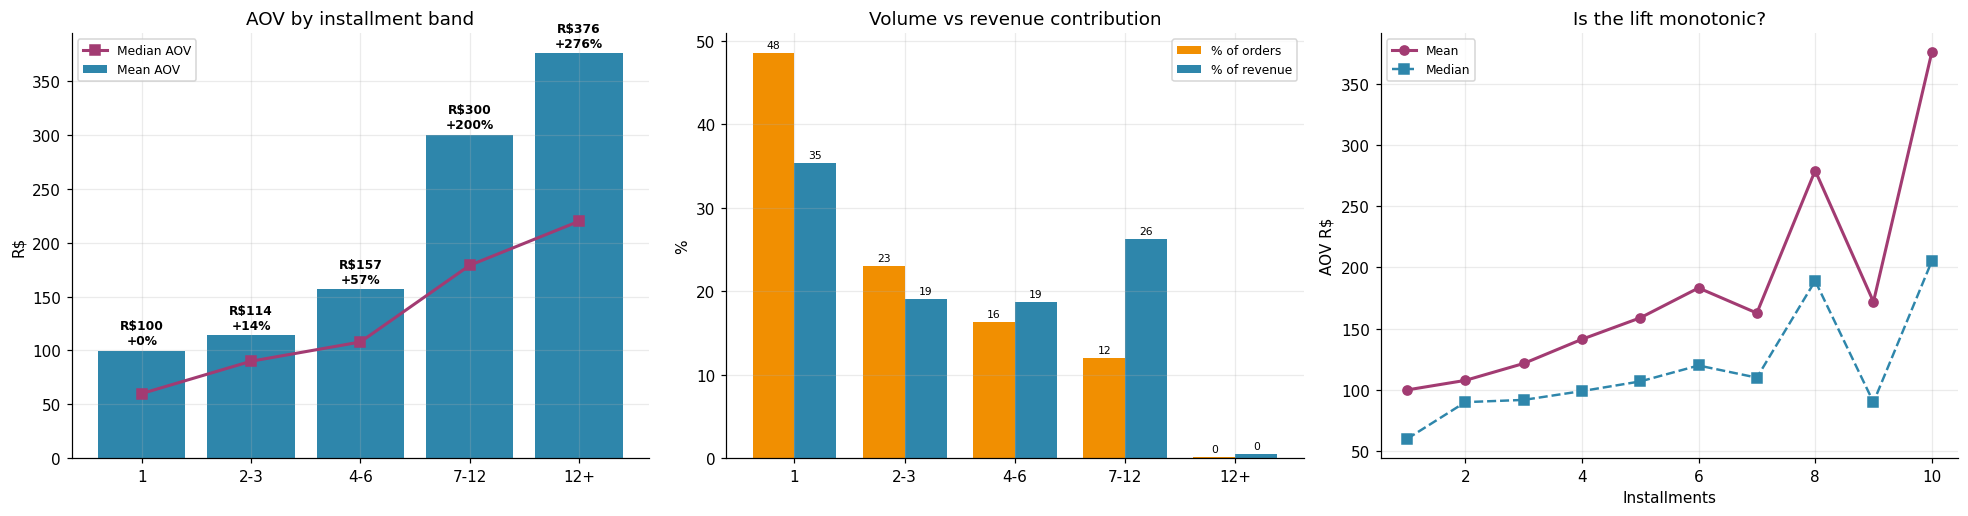

         aov     med      n         rev    lift  share  rev_share
band                                                             
1      99.94   59.99  46709  4668200.07    0.00   48.5       35.4
2-3   114.05   90.00  22100  2520450.16   14.11   23.0       19.1
4-6   157.05  107.85  15686  2463529.83   57.14   16.3       18.7
7-12  300.08  179.00  11535  3461472.87  200.26   12.0       26.3
12+   375.67  219.90    179    67244.92  275.89    0.2        0.5

single-payment AOV:  R$ 99.94  (48% of orders)
7-12 installment AOV: R$ 300.08  (lift +200%)
corr installments vs order revenue: 0.314

installment users (52% of orders) generate 65% of revenue


In [ ]:
ol['band'] = pd.cut(ol.installments, [0,1,3,6,12,99], labels=['1','2-3','4-6','7-12','12+'])
b = ol.groupby('band', observed=True).agg(
        aov=('revenue','mean'), med=('revenue','median'),
        n=('order_id','count'), rev=('revenue','sum'))
b['lift'] = (b.aov / b.aov.iloc[0] - 1) * 100
b['share'] = (b.n / b.n.sum() * 100).round(1)
b['rev_share'] = (b.rev / b.rev.sum() * 100).round(1)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))

ax[0].bar(b.index, b.aov, color='#2E86AB', label='Mean AOV')
ax[0].plot(b.index, b.med, color='#A23B72', marker='s', ms=6, lw=2, label='Median AOV')
ax[0].set_ylabel('R$'); ax[0].legend(fontsize=8)
for i, (v, l) in enumerate(zip(b.aov, b.lift)):
    ax[0].text(i, v+6, f'R${v:.0f}\n{l:+.0f}%', ha='center', fontsize=8, fontweight='bold')
ax[0].set_title('AOV by installment band')

w = .38; x = np.arange(len(b))
ax[1].bar(x-w/2, b.share, w, label='% of orders', color='#F18F01')
ax[1].bar(x+w/2, b.rev_share, w, label='% of revenue', color='#2E86AB')
ax[1].set_xticks(x); ax[1].set_xticklabels(b.index); ax[1].legend(fontsize=8)
ax[1].set_ylabel('%'); ax[1].set_title('Volume vs revenue contribution')
for i, (s_, r_) in enumerate(zip(b.share, b.rev_share)):
    ax[1].text(i-w/2, s_+.6, f'{s_:.0f}', ha='center', fontsize=7)
    ax[1].text(i+w/2, r_+.6, f'{r_:.0f}', ha='center', fontsize=7)

i2 = ol[ol.installments.between(1,12)].groupby('installments').revenue.agg(['mean','median','count'])
i2 = i2[i2['count'] >= 200]
ax[2].plot(i2.index, i2['mean'], marker='o', color='#A23B72', lw=2, label='Mean')
ax[2].plot(i2.index, i2['median'], marker='s', color='#2E86AB', lw=1.6, ls='--', label='Median')
ax[2].set_xlabel('Installments'); ax[2].set_ylabel('AOV R$')
ax[2].legend(fontsize=8); ax[2].set_title('Is the lift monotonic?')

plt.tight_layout(); plt.show()

print(b.round(2).to_string())
print(f"\nsingle-payment AOV:  R$ {b.aov.iloc[0]:.2f}  ({b.share.iloc[0]:.0f}% of orders)")
print(f"7-12 installment AOV: R$ {b.aov.loc['7-12']:.2f}  (lift {b.lift.loc['7-12']:+.0f}%)")
print(f"corr installments vs order revenue: {ol[['installments','revenue']].corr().iloc[0,1]:.3f}")
print(f"\ninstallment users ({100-b.share.iloc[0]:.0f}% of orders) generate {100-b.rev_share.iloc[0]:.0f}% of revenue")

H5 — Boleto and credit card serve different demand

Statement: Boleto users show lower AOV and a different category mix than credit card users. Payment mix is therefore a revenue-mix variable, not a neutral processing detail.

Why it matters: Boleto has no installment facility and settles slower, but it serves customers without credit access — 20.3% of transactions. Understanding what they buy and how much they spend determines whether promoting boleto expands the market or dilutes basket size. Proved if AOV and category composition differ materially.

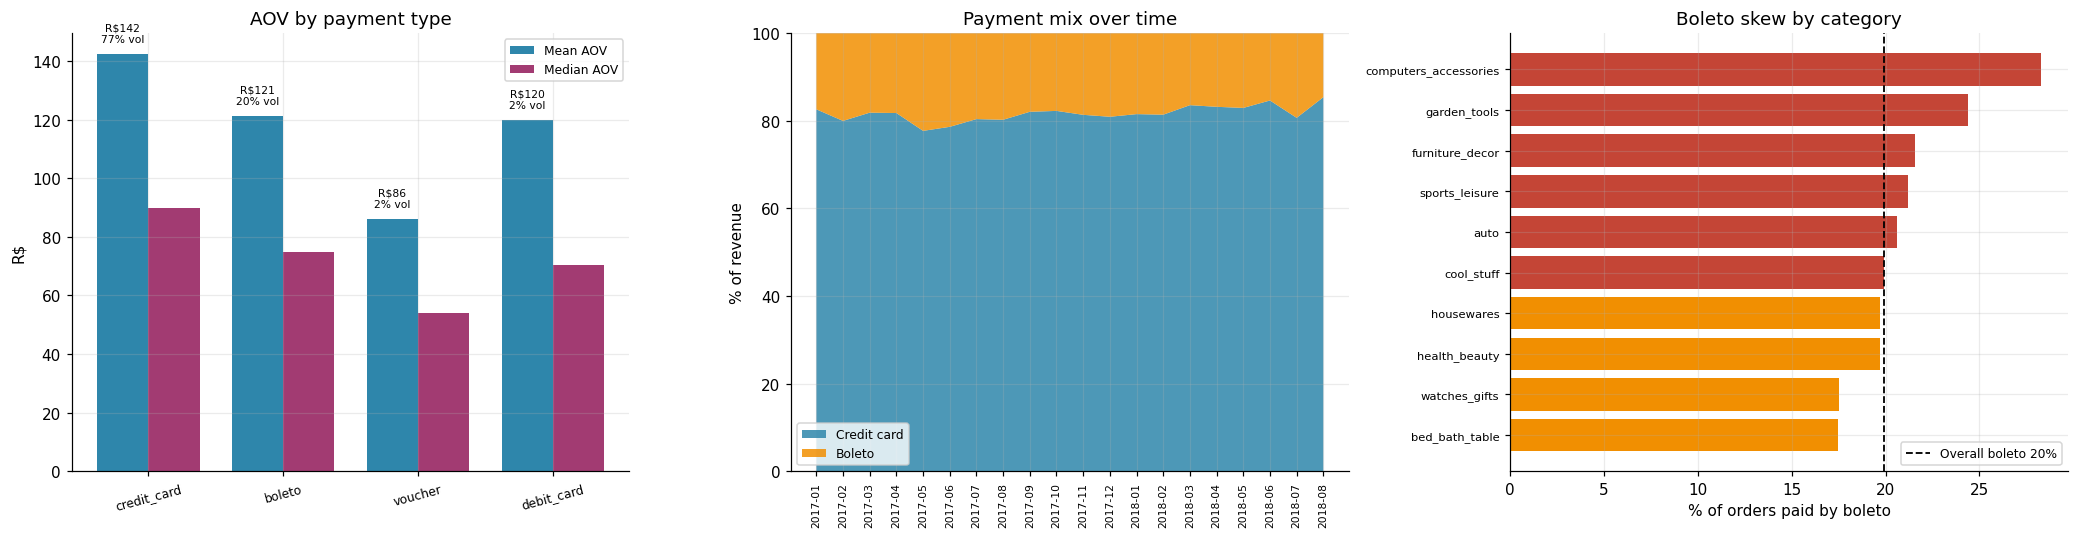

                 aov    med      n          rev  items  share  rev_share
payment_type                                                            
credit_card   142.40  89.90  74095  10551425.80   1.14   77.0       80.1
boleto        121.39  74.90  19140   2323387.90   1.17   19.9       17.6
voucher        86.05  54.00   1494    128554.86   1.08    1.6        1.0
debit_card    119.88  70.45   1482    177658.57   1.11    1.5        1.3

boleto vs credit AOV gap: -14.8%
boleto = 19.9% of orders but 17.6% of revenue

CATEGORY BOLETO SKEW (top-10 revenue categories):
                       boleto  credit_card   price
category                                          
bed_bath_table          17.46        82.54   79.90
watches_gifts           17.54        82.46  129.00
health_beauty           19.69        80.31   79.99
housewares              19.71        80.29   59.90
cool_stuff              19.93        80.07  129.99
auto                    20.58        79.42   87.00
sports_leisure         

In [ ]:
p = ol[ol.payment_type.isin(['credit_card','boleto','debit_card','voucher'])]
agg = p.groupby('payment_type').agg(aov=('revenue','mean'), med=('revenue','median'),
        n=('order_id','count'), rev=('revenue','sum'), items=('items','mean'))
agg['share'] = (agg.n / agg.n.sum() * 100).round(1)
agg['rev_share'] = (agg.rev / agg.rev.sum() * 100).round(1)
agg = agg.sort_values('n', ascending=False)

fig, ax = plt.subplots(1, 3, figsize=(19, 5))

x = np.arange(len(agg)); w = .38
ax[0].bar(x-w/2, agg.aov, w, label='Mean AOV', color='#2E86AB')
ax[0].bar(x+w/2, agg.med, w, label='Median AOV', color='#A23B72')
ax[0].set_xticks(x); ax[0].set_xticklabels(agg.index, rotation=15, fontsize=8)
ax[0].set_ylabel('R$'); ax[0].legend(fontsize=8); ax[0].set_title('AOV by payment type')
for i, (v, s_) in enumerate(zip(agg.aov, agg.share)):
    ax[0].text(i-w/2, v+4, f'R${v:.0f}\n{s_:.0f}% vol', ha='center', fontsize=7)

mix = (fs[fs.payment_type.isin(['credit_card','boleto'])]
       .pivot_table(index='purchase_month', columns='payment_type', values='price', aggfunc='sum'))
mix = (mix.div(mix.sum(1), axis=0)*100).loc['2017-01':'2018-08']
ax[1].stackplot(mix.index, mix.credit_card, mix.boleto,
                labels=['Credit card','Boleto'], colors=['#2E86AB','#F18F01'], alpha=.85)
ax[1].legend(loc='lower left', fontsize=8); ax[1].tick_params(axis='x', rotation=90, labelsize=7)
ax[1].set_ylabel('% of revenue'); ax[1].set_ylim(0,100)
ax[1].set_title('Payment mix over time')

t = fs[fs.payment_type.isin(['credit_card','boleto'])]
top10 = t.groupby('category').price.sum().nlargest(10).index
cm = t[t.category.isin(top10)].pivot_table(index='category', columns='payment_type',
        values='order_id', aggfunc='count')
cm = (cm.div(cm.sum(1), axis=0)*100).sort_values('boleto')
base_b = agg.loc['boleto','share']
ax[2].barh(cm.index, cm.boleto,
           color=['#C44536' if v>base_b else '#F18F01' for v in cm.boleto])
ax[2].axvline(base_b, ls='--', c='k', lw=1.2, label=f'Overall boleto {base_b:.0f}%')
ax[2].legend(fontsize=8); ax[2].set_xlabel('% of orders paid by boleto')
ax[2].tick_params(axis='y', labelsize=7.5); ax[2].set_title('Boleto skew by category')

plt.tight_layout(); plt.show()

print(agg.round(2).to_string())
gap = (agg.loc['boleto','aov'] / agg.loc['credit_card','aov'] - 1) * 100
print(f"\nboleto vs credit AOV gap: {gap:+.1f}%")
print(f"boleto = {agg.loc['boleto','share']:.1f}% of orders but {agg.loc['boleto','rev_share']:.1f}% of revenue")

print("\nCATEGORY BOLETO SKEW (top-10 revenue categories):")
det = cm.join(t.groupby('category').agg(price=('price','median')))
print(det.round(2).to_string())

t2 = t.copy()
t2['pband'] = pd.qcut(t2.price, 5, labels=['P1 cheap','P2','P3','P4','P5 premium'])
pb = t2.pivot_table(index='pband', columns='payment_type', values='order_id',
                    aggfunc='count', observed=True)
print("\nBOLETO SHARE BY PRICE BAND:")
print((pb.div(pb.sum(1), axis=0)*100).round(1).to_string())

In [ ]:
!ls -lh /content/drive/MyDrive/olist_project/processed/
!ls -lh /content/drive/MyDrive/olist_project/sql/

total 104M
-rw------- 1 root root 21M Jul 31 15:37 fact_delivery_clean.csv
-rw------- 1 root root 21M Jul 31 15:34 fact_delivery.csv
-rw------- 1 root root 21M Jul 31 15:37 fact_delivery_flagged.csv
-rw------- 1 root root 21M Jul 31 15:37 fact_delivery_legs.csv
-rw------- 1 root root 22M Jul 31 15:34 fact_sales.csv
total 3.5K
-rw------- 1 root root 1.8K Jul 31 15:34 fact_delivery.sql
-rw------- 1 root root 1.2K Jul 31 15:34 fact_sales.sql


In [ ]:
findings = """
# OLIST — FINDINGS LOG

## PROJECT 1 (n=94,819 delivered orders, Jan-17 to Aug-18)
OTDR 91.79% | median delivery 10.3d | promised 23.2d | buffer 13.0d
H1 CONFIRMED — satisfaction cliff at day 3 (drop -0.648); score 4.14→3.06 (-26.1%);
   floor ~1.7 by day 7. Late orders 7,788 (8.21%); 2,642 (33.9%) in recoverable 1-3d window.
   %1-2 star by bucket: 9 / 19 / 60 / 77 / 76
H2 CONFIRMED — ETA padded 13 days; buffer WIDENED as ops improved (2018-03 onward)
H3 REJECTED — carrier owns 74% of time, r=0.915 w/ total, -0.302 w/ score.
   Seller handling 23%, r=0.407. Fix is carrier/lane, not seller SLA.
H4 CONFIRMED — rate: AL 23.6%, MA 20.0%, PI 16.2%; volume: RJ dominant (8,017 SP-lane
   orders @ 15.72% late). Seller supply 70.7% SP-concentrated.
H5 CONFIRMED — D10 = 34.5% of all 1-2 star reviews; slowest 2 deciles = 45.5% from 20% of orders.
DQ NOTE — p99.5 outlier exclusion TESTED AND REJECTED: those 479 orders had 98.5% late rate,
   1.95 avg score vs 8.2%/4.15 baseline. Retained for satisfaction analysis.

## PROJECT 2 (n=109,880 line items, 96,211 orders)
Revenue R$13,181,027 | freight R$2,192,093 | freight-to-sales 16.63%
AOV mean R$137.00 / median R$86.50 | 1.14 items/order | 72 categories
H1 CONFIRMED — orders +747%, revenue +650%, AOV -11% (corr w/ time -0.229). Volume-driven.
H2 CONFIRMED — break-even R$47.49 (freight ratio crosses 30%). D1 ratio 78.5%, D10 6.4%.
   4,000 items (3.64%) freight > price, median price R$13.90, but only 0.53% of revenue.
H3 REVISED then CONFIRMED — Spearman rho=-0.219 p=0.214 (n.s.): revenue rank independent of
   freight health. Spread 5.4x (0.116 watches_gifts → 0.627 electronics).
   MECHANISM: price r=-0.727, weight r=-0.052. Price drives ratio, NOT bulk.
   CORROBORATION: both action-list categories sit below H2 break-even. Mean fr 0.441 below
   vs 0.225 above. Kill list: electronics (fr 0.627, R$21.89), telephony (0.434, R$29.99).
H4 CONFIRMED — AOV by band: 1=R$99.94, 2-3=R$114, 4-6=R$157, 7-12=R$300 (+200%).
   Installment users 52% of orders → 65% of revenue. 7-12 band: 12% orders, 26% revenue.
   Monotonic on median too (R$60→R$219). Caveat: reverse causality; 12+ band n=179.
H5 CONFIRMED — boleto AOV R$121.39 vs credit R$142.40 (-14.8%). 19.9% orders, 17.6% revenue.
   Skew: computers_accessories 28.3%, garden_tools 24.4% vs bed_bath_table 17.5%.
   Mix stable ~80/20 throughout.

## RECOMMENDATIONS
P1: escalate at day 2 | prioritise SP→RJ/BA/CE by volume | replace OTDR w/ promise-adjusted metric
P2: R$47.49 price floor | reprice electronics + telephony (3.80% rev exposure) |
    grow watches_gifts/cool_stuff/perfumery (fr<0.18) | extend installments R$100-250 |
    treat boleto as distinct segment

## DATA RULES APPLIED
delivered status only (97.02%) | Jan-2017 to Aug-2018 | 8 null delivery dates dropped |
reviews deduped by latest creation date | payments pre-aggregated (1.04 fan-out) |
negative legs flagged & excluded | seller_state/payment_type = MIN() on multi-seller orders

## LIMITATIONS
No cost/margin data in Olist — freight ratio and AOV used as value proxies, profitability
not computable. Multi-seller orders (1.14%) use MIN() for seller_state and payment_type.
1.42% of products have no category (labelled 'unknown', retained). Review text is Portuguese,
present on 40.2% of orders only. Dataset ends Aug-2018; Sep/Oct-2018 partial months excluded.
"""

with open('/content/drive/MyDrive/olist_project/FINDINGS.md','w') as f:
    f.write(findings)
print("saved to Drive")

saved to Drive


In [ ]:
!cat /content/drive/MyDrive/olist_project/FINDINGS.md | head -20
from google.colab import files
files.download('/content/drive/MyDrive/olist_project/FINDINGS.md')


# OLIST — FINDINGS LOG

## PROJECT 1 (n=94,819 delivered orders, Jan-17 to Aug-18)
OTDR 91.79% | median delivery 10.3d | promised 23.2d | buffer 13.0d
H1 CONFIRMED — satisfaction cliff at day 3 (drop -0.648); score 4.14→3.06 (-26.1%);
   floor ~1.7 by day 7. Late orders 7,788 (8.21%); 2,642 (33.9%) in recoverable 1-3d window.
   %1-2 star by bucket: 9 / 19 / 60 / 77 / 76
H2 CONFIRMED — ETA padded 13 days; buffer WIDENED as ops improved (2018-03 onward)
H3 REJECTED — carrier owns 74% of time, r=0.915 w/ total, -0.302 w/ score.
   Seller handling 23%, r=0.407. Fix is carrier/lane, not seller SLA.
H4 CONFIRMED — rate: AL 23.6%, MA 20.0%, PI 16.2%; volume: RJ dominant (8,017 SP-lane
   orders @ 15.72% late). Seller supply 70.7% SP-concentrated.
H5 CONFIRMED — D10 = 34.5% of all 1-2 star reviews; slowest 2 deciles = 45.5% from 20% of orders.
DQ NOTE — p99.5 outlier exclusion TESTED AND REJECTED: those 479 orders had 98.5% late rate,
   1.95 avg score vs 8.2%/4.15 baseline. Retained for sat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!mkdir -p /content/drive/MyDrive/olist_project/notebooks
!mv "/content/drive/MyDrive/Colab Notebooks/olist_01_etl_and_eda.ipynb" \
    /content/drive/MyDrive/olist_project/notebooks/
!ls /content/drive/MyDrive/olist_project/notebooks/

olist_01_etl_and_eda.ipynb
